# Ten internal nodes along the human tree

`01`-`04` use three nodes. This one widens to ten reconstructed nodes that were picked
for a reason: after the class 1 / class 2 split, `node_6 -> 12 -> 21 -> 32 -> 44` is a
nested chain descending the class 2 trunk, so the repertoire can be followed step by
step down a single lineage rather than compared across a fork.

Same density fill as the rest of the folder. Only reconstructed nodes appear here;
extant receptors enter in `03` and `04`.

In [1]:
import sys
sys.path.append("../../scripts")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, fisher_exact

from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import Patch
from plotting_functions import custom_plots, FIGSIZE
from ancestral_sets import load_ancestral, functional_groups, descriptors, \
                           decay_table, edge_table, node_topology, node_sets, \
                           asr_tree, density_grid, save_fig, save_table, \
                           FG_SMARTS, DESCRIPTORS, PATTERN_ORDER, PATTERN_LABELS, \
                           TEN_NODES, CLASSES
plt.rcParams.update(custom_plots())

COMMON_COL, CLASS1_COL, CLASS2_COL = "#5F6A72", "#7f1734", "#557c99"
NODE_COL = {"common_ancestor": COMMON_COL, "class1_ancestor": CLASS1_COL, "class2_ancestor": CLASS2_COL}

# ten CVD-safe categorical colours, fixed order
PAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7",
       "#e34948", "#e87ba4", "#eb6834", "#0098c7", "#9c4d00"]
NCOL = {n: PAL[i] for i, n in enumerate(TEN_NODES)}
THRESH = None   # None = shared density fill; a number restores an absolute cut

topo = node_topology(TEN_NODES, threshold=THRESH)
sets = node_sets(TEN_NODES, threshold=THRESH)
print(topo.to_string(index=False))
save_table(topo, "05_topology")

 node  parent  depth  branch_len  n_leaves  frac_class_I OR_class  n_ligands  n_retained  n_gained  n_lost ancestors_in_set
    1  node_0      1    1.512110       433         0.143    mixed         21         NaN       NaN     NaN                 
    2  node_1      2    0.487478        62         1.000  Class_I         21         4.0      17.0    17.0                1
    3  node_1      2    0.357385       371         0.000 Class_II          8         7.0       1.0    14.0                1
    4  node_2      3    0.473190        55         1.000  Class_I         23        12.0      11.0     9.0              1;2
    5  node_2      3    0.737785         7         1.000  Class_I         21        13.0       8.0     8.0              1;2
    6  node_3      3    0.547405       370         0.000 Class_II         27         7.0      20.0     1.0              1;3
   12  node_6      4    0.129691       365         0.000 Class_II         10        10.0       0.0    17.0            1;3;6
   21 no

## Where the nodes sit

Depth from the root against repertoire size. The chain is drawn by joining each node to
its nearest ancestor that is also in the set.

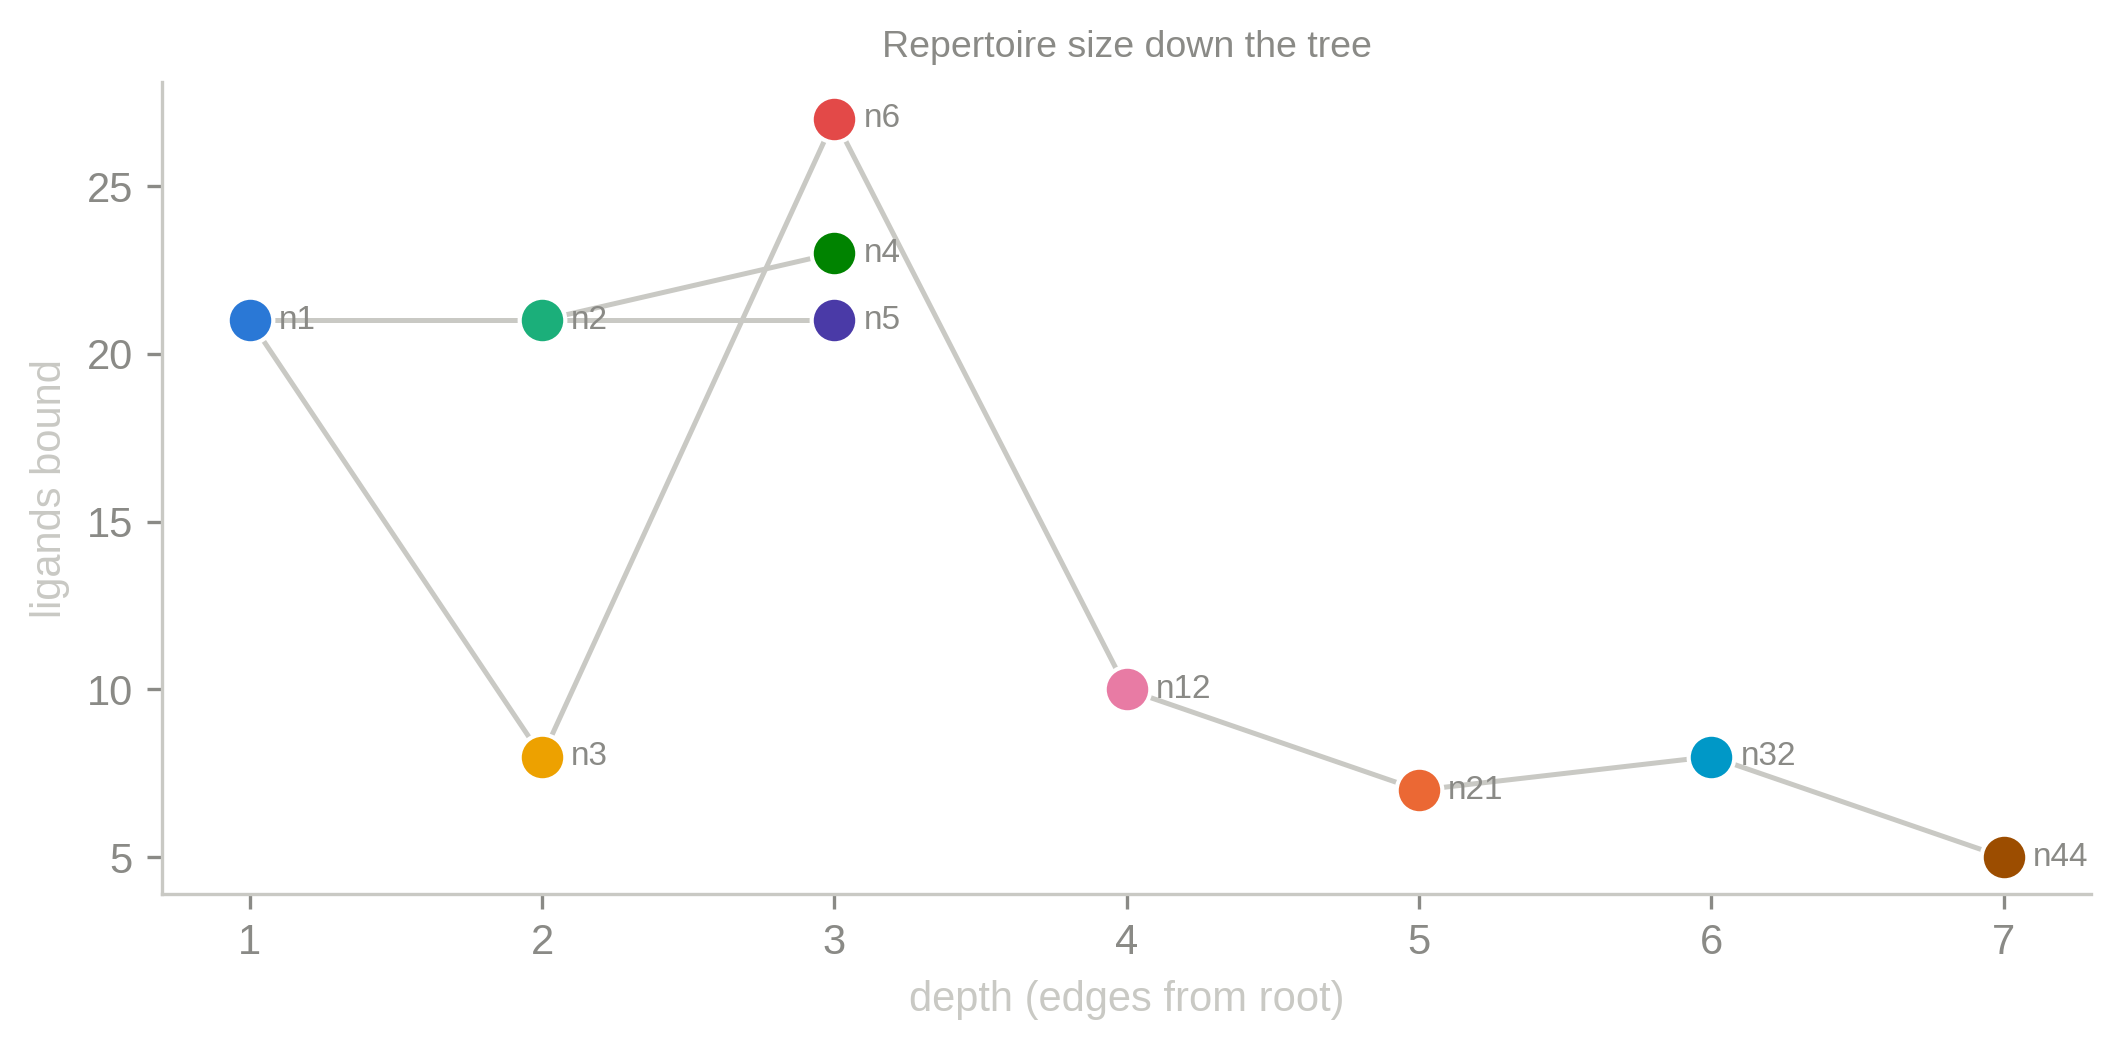

In [2]:
nearest = {}
for r in topo.itertuples():
    within = [int(a) for a in r.ancestors_in_set.split(";") if a]
    nearest[r.node] = max(within, key=lambda m: int(topo.loc[topo.node == m, "depth"].iloc[0])) \
                      if within else None

depth = dict(zip(topo.node, topo.depth))
nlig = dict(zip(topo.node, topo.n_ligands))

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.8, FIGSIZE[1] * 1.2))
for n, p in nearest.items():
    if p is not None:
        ax.plot([depth[p], depth[n]], [nlig[p], nlig[n]], color="#c9c9c4", lw=1.2, zorder=1)
for r in topo.itertuples():
    ax.scatter(r.depth, r.n_ligands, s=120, color=NCOL[r.node], zorder=3,
               edgecolor="white", lw=1.0)
    ax.annotate(f"n{r.node}", (r.depth, r.n_ligands), xytext=(7, 0),
                textcoords="offset points", va="center", fontsize=8)
ax.set_xlabel("depth (edges from root)"); ax.set_ylabel("ligands bound")
ax.set_title("Repertoire size down the tree", fontsize=9)
plt.tight_layout(); save_fig(fig, "05_lineage"); plt.show()

## OR class of each node

Assigned from the classes of the descendant human leaves: >=90% class I is class I,
<=10% is class II, anything between is mixed.

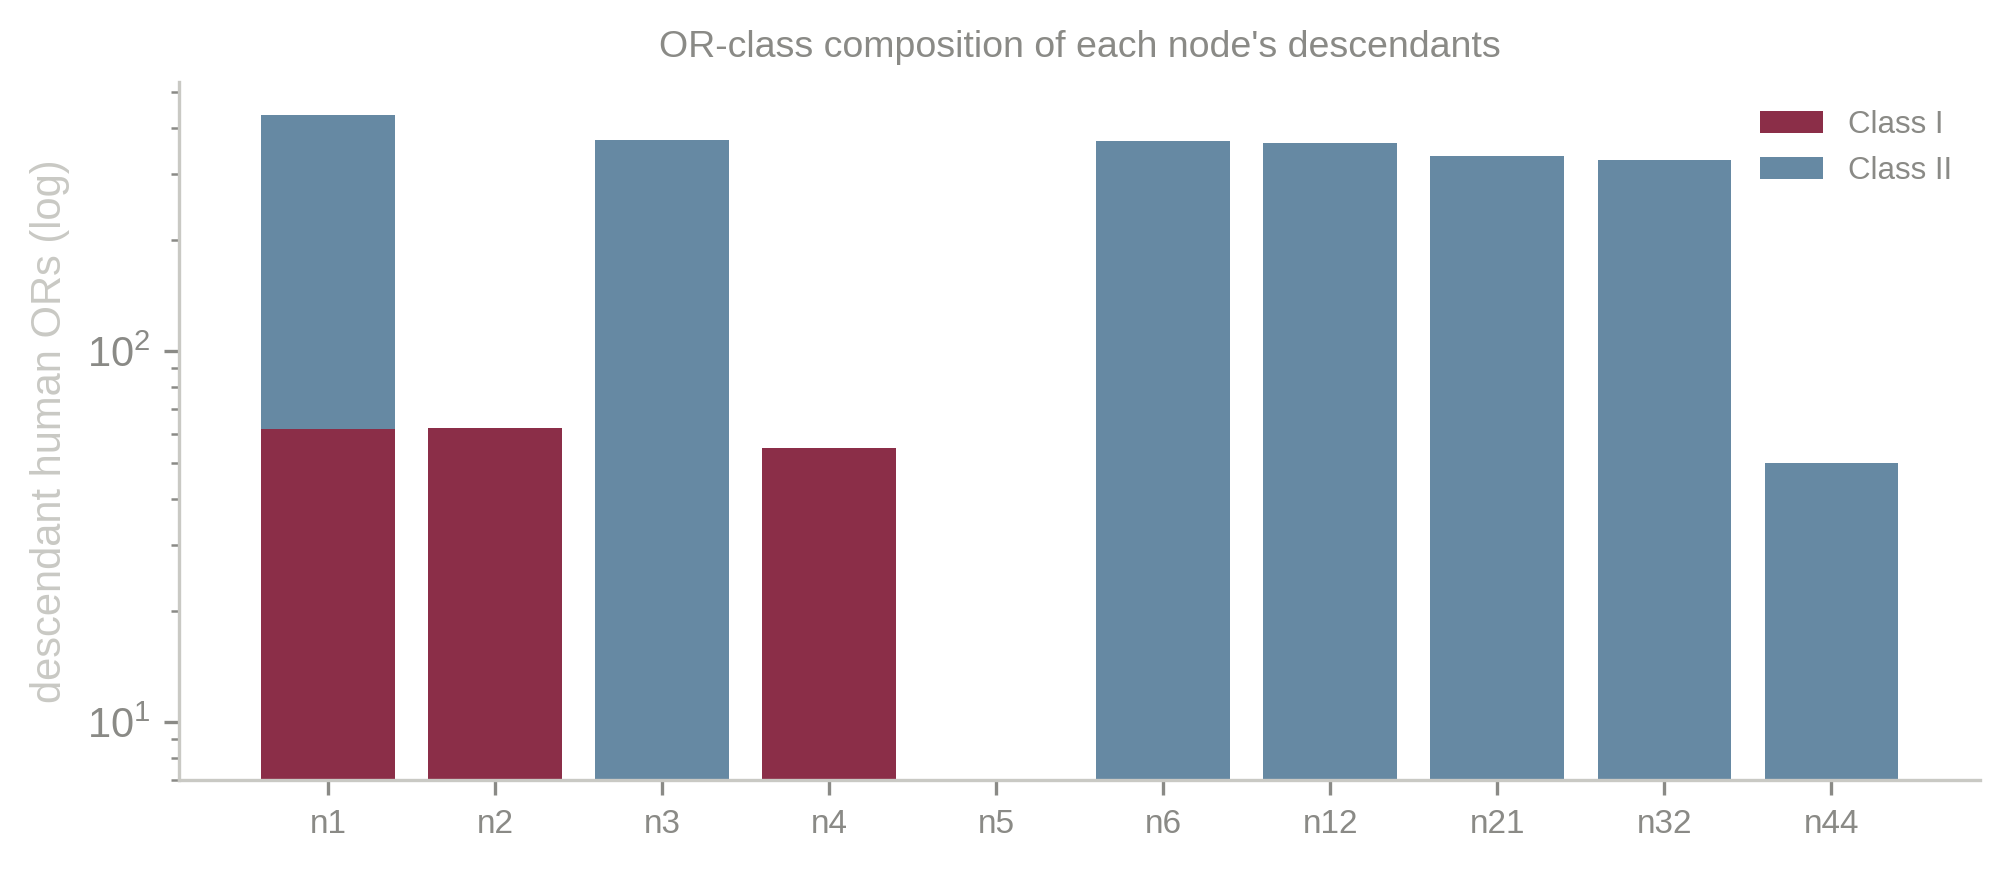

 node OR_class  n_leaves  frac_class_I  n_ligands
    1    mixed       433         0.143         21
    2  Class_I        62         1.000         21
    3 Class_II       371         0.000          8
    4  Class_I        55         1.000         23
    5  Class_I         7         1.000         21
    6 Class_II       370         0.000         27
   12 Class_II       365         0.000         10
   21 Class_II       337         0.000          7
   32 Class_II       328         0.000          8
   44 Class_II        50         0.000          5


In [3]:
fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.7, FIGSIZE[1]))
x = np.arange(len(topo))
n_i = topo.frac_class_I * topo.n_leaves
n_ii = (1 - topo.frac_class_I) * topo.n_leaves
ax.bar(x, n_i, color=CLASS1_COL, label="Class I", alpha=0.9)
ax.bar(x, n_ii, bottom=n_i, color=CLASS2_COL, label="Class II", alpha=0.9)
ax.set_yscale("log"); ax.set_ylabel("descendant human ORs (log)")
ax.set_xticks(x); ax.set_xticklabels([f"n{n}" for n in topo.node], fontsize=8)
ax.legend(frameon=False, fontsize=7.5)
ax.set_title("OR-class composition of each node's descendants", fontsize=9)
plt.tight_layout(); save_fig(fig, "05_node_or_class"); plt.show()

print(topo[["node", "OR_class", "n_leaves", "frac_class_I", "n_ligands"]].to_string(index=False))

## Overlap between the ten repertoires

union of the ten: 61 ligands
bound by all ten: 1 ligands


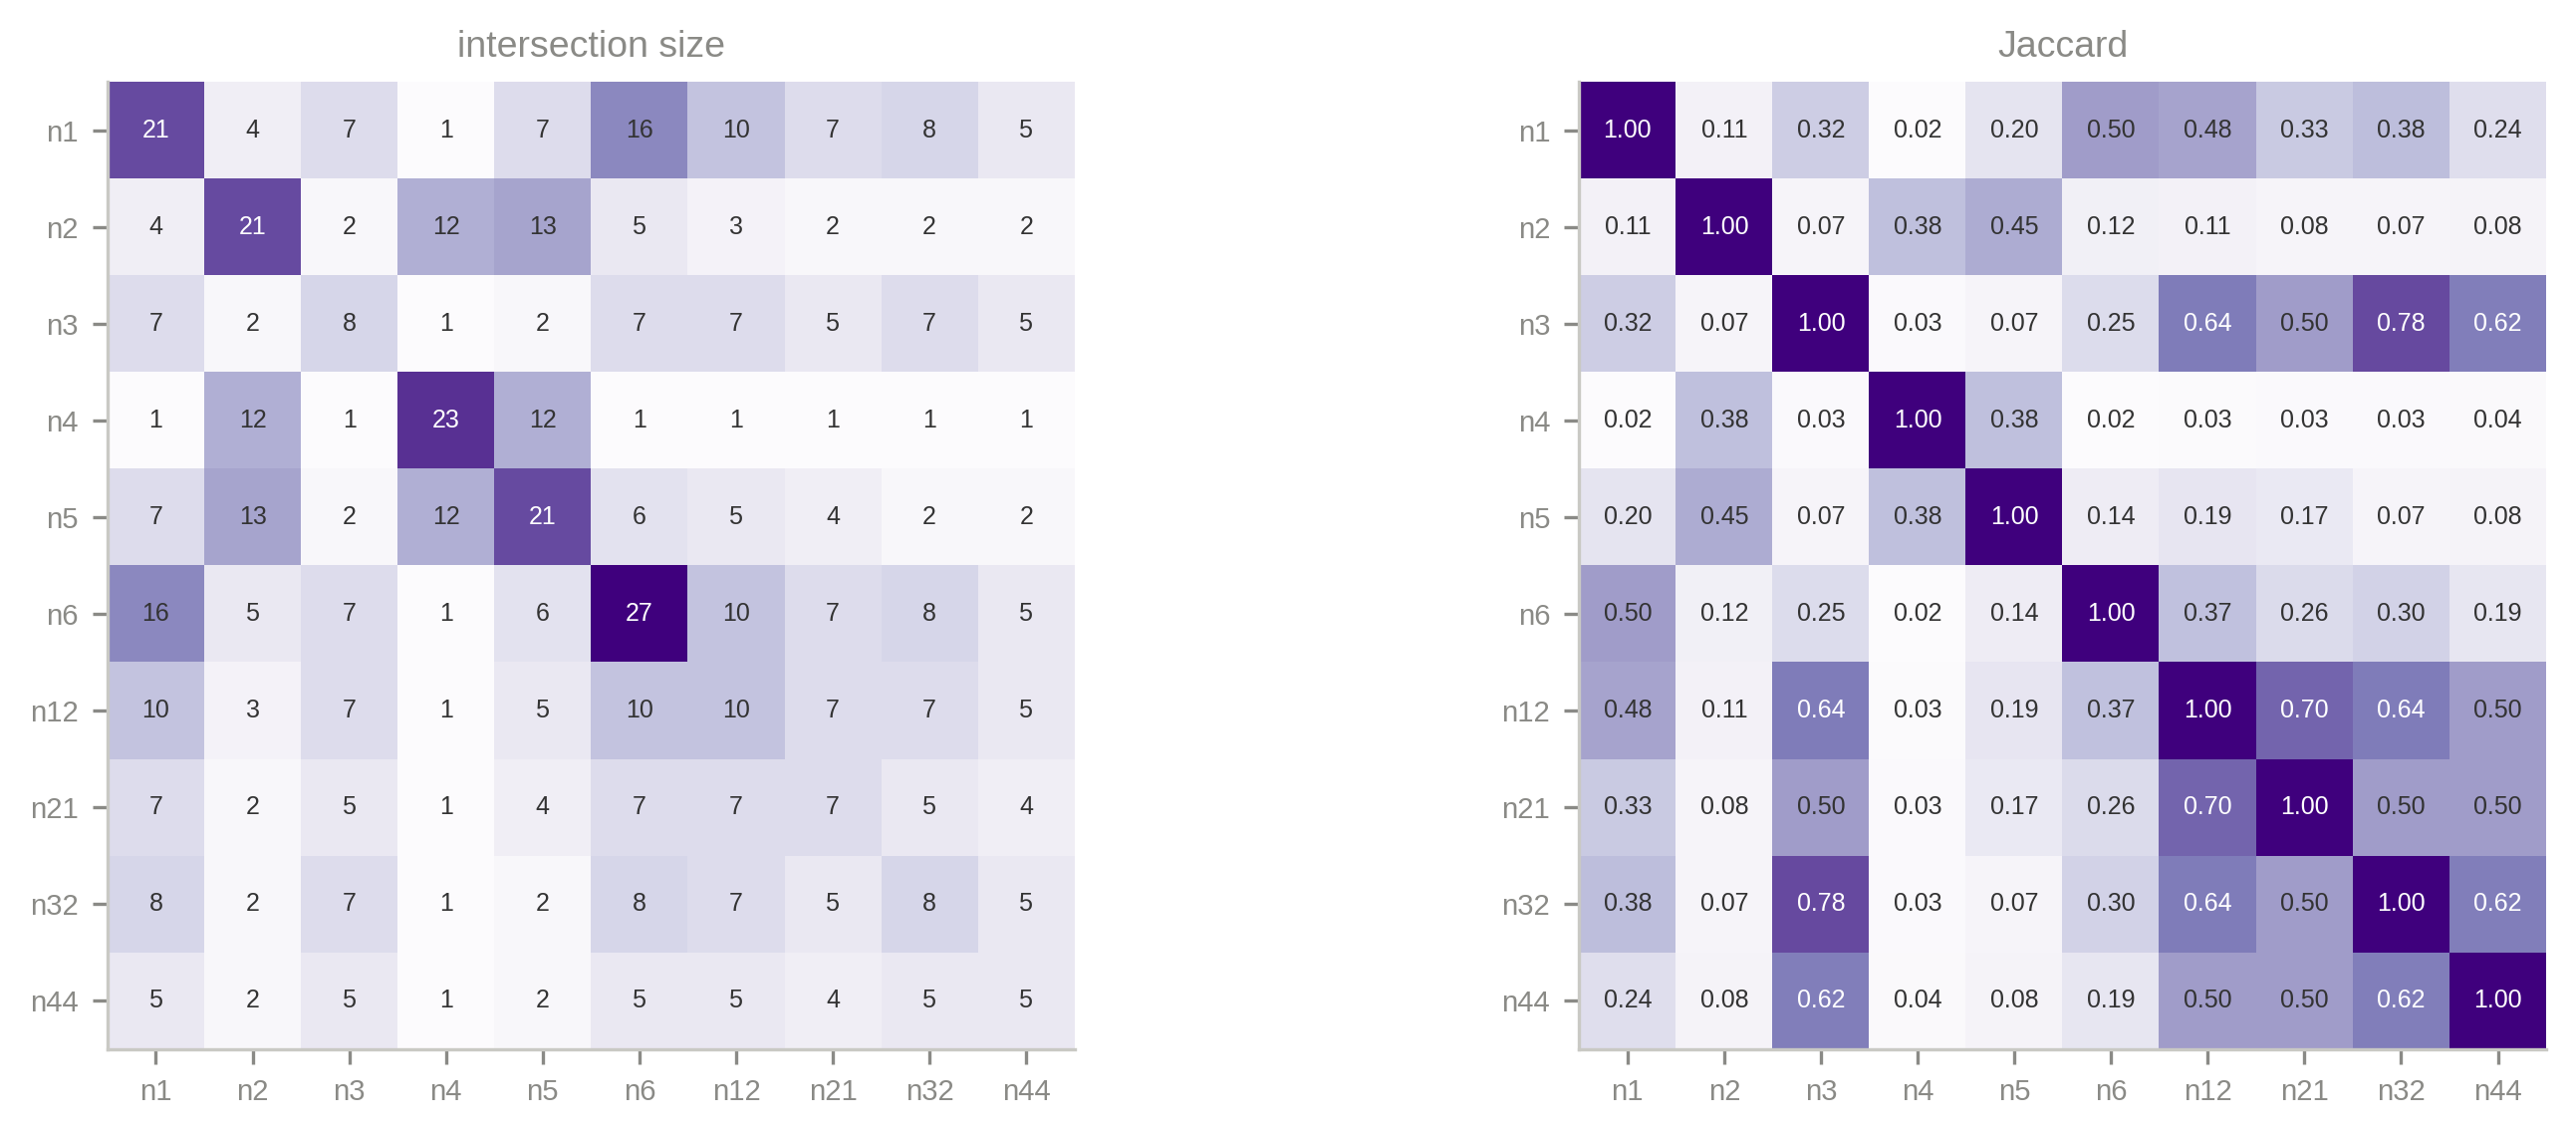

In [4]:
J = pd.DataFrame(index=TEN_NODES, columns=TEN_NODES, dtype=float)
I = pd.DataFrame(index=TEN_NODES, columns=TEN_NODES, dtype=int)
for a in TEN_NODES:
    for b in TEN_NODES:
        inter = len(sets[a] & sets[b]); union = len(sets[a] | sets[b])
        I.loc[a, b] = inter
        J.loc[a, b] = inter / union if union else 0.0
save_table(J.round(4).reset_index().rename(columns={"index": "node"}), "05_pairwise_jaccard")

union_all = set().union(*sets.values())
print(f"union of the ten: {len(union_all)} ligands")
print(f"bound by all ten: {len(set.intersection(*sets.values()))} ligands")

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2.6, FIGSIZE[1] * 1.3))
for ax, M, title, fmt in [(axes[0], I.astype(float), "intersection size", ".0f"),
                          (axes[1], J.astype(float), "Jaccard", ".2f")]:
    im = ax.imshow(M.values, cmap="Purples")
    ax.set_xticks(range(len(TEN_NODES))); ax.set_yticks(range(len(TEN_NODES)))
    ax.set_xticklabels([f"n{n}" for n in TEN_NODES], fontsize=7)
    ax.set_yticklabels([f"n{n}" for n in TEN_NODES], fontsize=7)
    cut = M.values.max() * 0.6
    for i in range(len(TEN_NODES)):
        for j in range(len(TEN_NODES)):
            ax.text(j, i, format(M.values[i, j], fmt), ha="center", va="center",
                    fontsize=6, color="white" if M.values[i, j] > cut else "#333")
    ax.set_title(title, fontsize=9)
plt.tight_layout(); save_fig(fig, "05_pairwise_overlap"); plt.show()

## Intersection structure

Which combinations of nodes share a ligand. Because the nodes are nested, most ligands
fall into a small number of patterns.

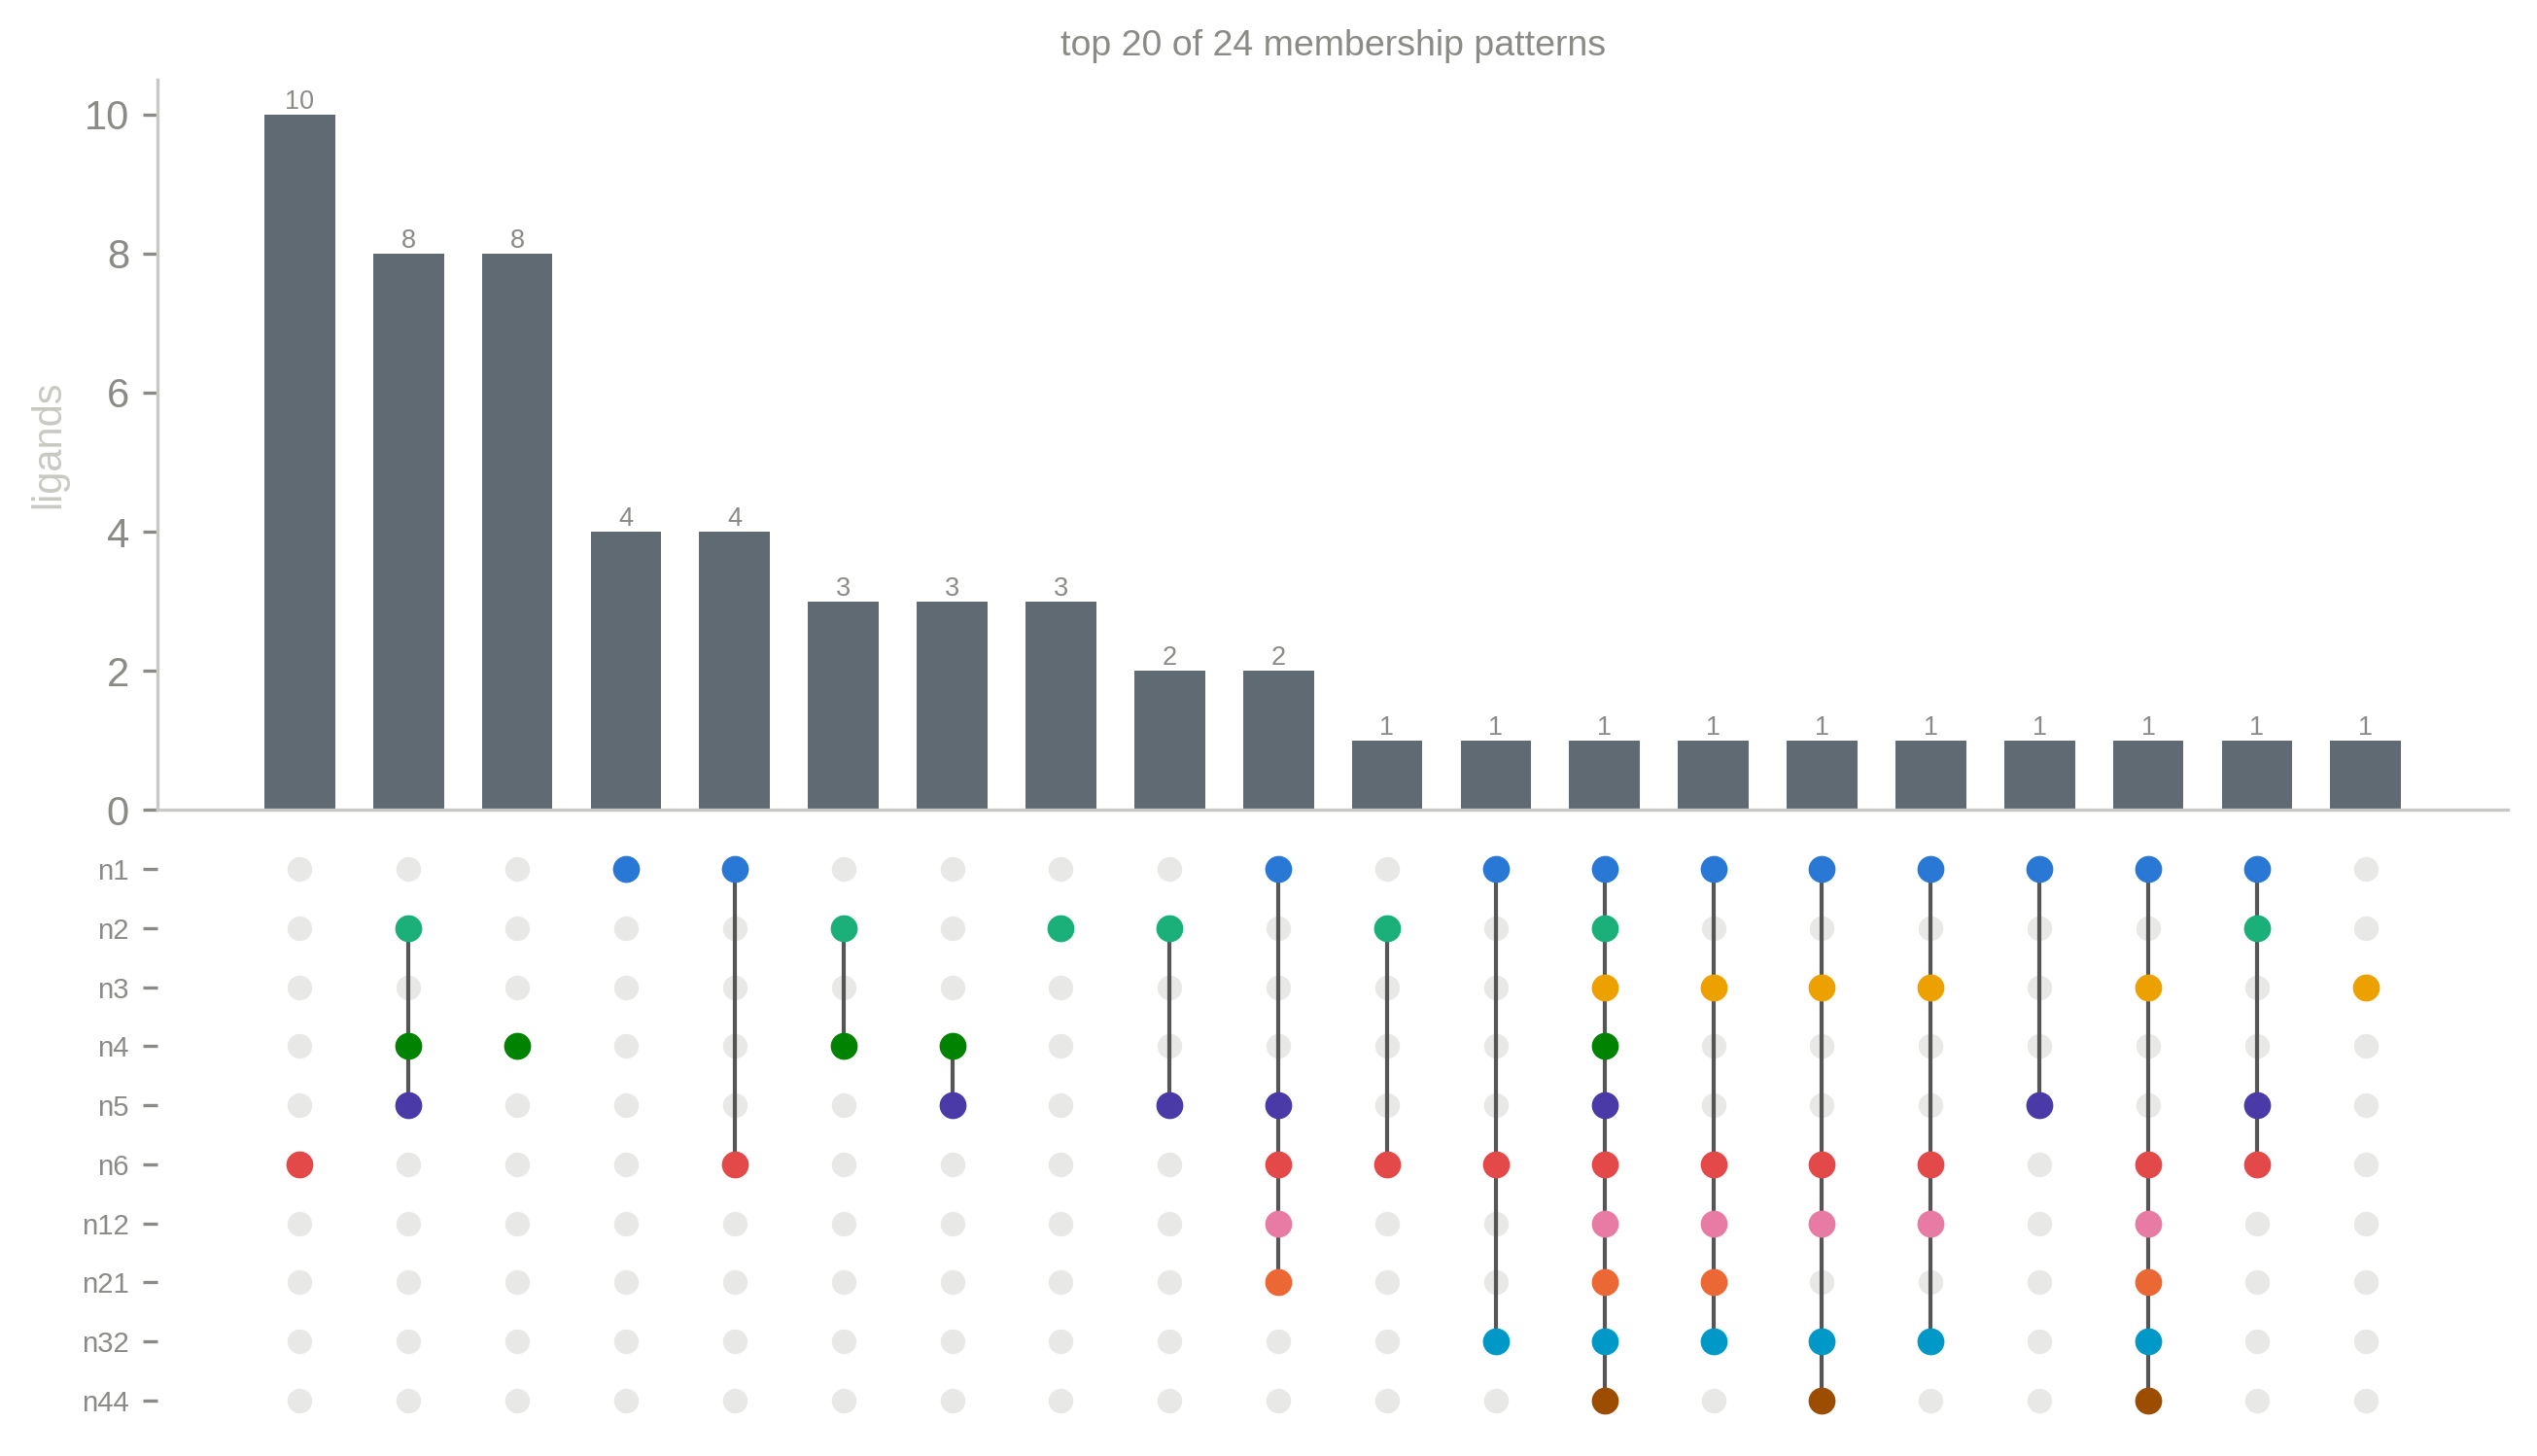

In [5]:
member = {s: tuple(s in sets[n] for n in TEN_NODES) for s in union_all}
counts = pd.Series(list(member.values())).value_counts()
top = counts.head(20)

fig = plt.figure(figsize=(FIGSIZE[0] * 2.6, FIGSIZE[1] * 2.0))
gs = fig.add_gridspec(2, 1, height_ratios=[2.0, 1.6], hspace=0.05)
axb = fig.add_subplot(gs[0]); axm = fig.add_subplot(gs[1], sharex=axb)

xs = np.arange(len(top))
axb.bar(xs, top.values, color="#5F6A72", width=0.65)
for xi, v in zip(xs, top.values):
    axb.text(xi, v, str(v), ha="center", va="bottom", fontsize=6.5)
axb.set_ylabel("ligands"); axb.tick_params(labelbottom=False)

for yi, n in enumerate(TEN_NODES):
    axm.scatter(xs, [yi] * len(xs), s=26, color="#e8e8e6", zorder=1)
    on = [xi for xi, m in zip(xs, top.index) if m[yi]]
    axm.scatter(on, [yi] * len(on), s=32, color=NCOL[n], zorder=3)
for xi, m in zip(xs, top.index):
    idx = [yi for yi in range(len(TEN_NODES)) if m[yi]]
    if len(idx) > 1:
        axm.plot([xi, xi], [min(idx), max(idx)], color="#555", lw=1.0, zorder=2)
axm.set_yticks(range(len(TEN_NODES)))
axm.set_yticklabels([f"n{n}" for n in TEN_NODES], fontsize=7)
axm.set_xticks([]); axm.invert_yaxis()
for sp in ["top", "right", "bottom", "left"]: axm.spines[sp].set_visible(False)
axb.set_title(f"top {len(top)} of {len(counts)} membership patterns", fontsize=9)
save_fig(fig, "05_upset"); plt.show()

## Gains and losses against the immediate parent

The parent comes from the full ASR matrix, so it need not itself be one of the ten.

 node  parent  n_ligands  n_retained  n_gained  n_lost
    2  node_1         21         4.0      17.0    17.0
    3  node_1          8         7.0       1.0    14.0
    4  node_2         23        12.0      11.0     9.0
    5  node_2         21        13.0       8.0     8.0
    6  node_3         27         7.0      20.0     1.0
   12  node_6         10        10.0       0.0    17.0
   21 node_12          7         7.0       0.0     3.0
   32 node_21          8         5.0       3.0     2.0
   44 node_32          5         5.0       0.0     3.0


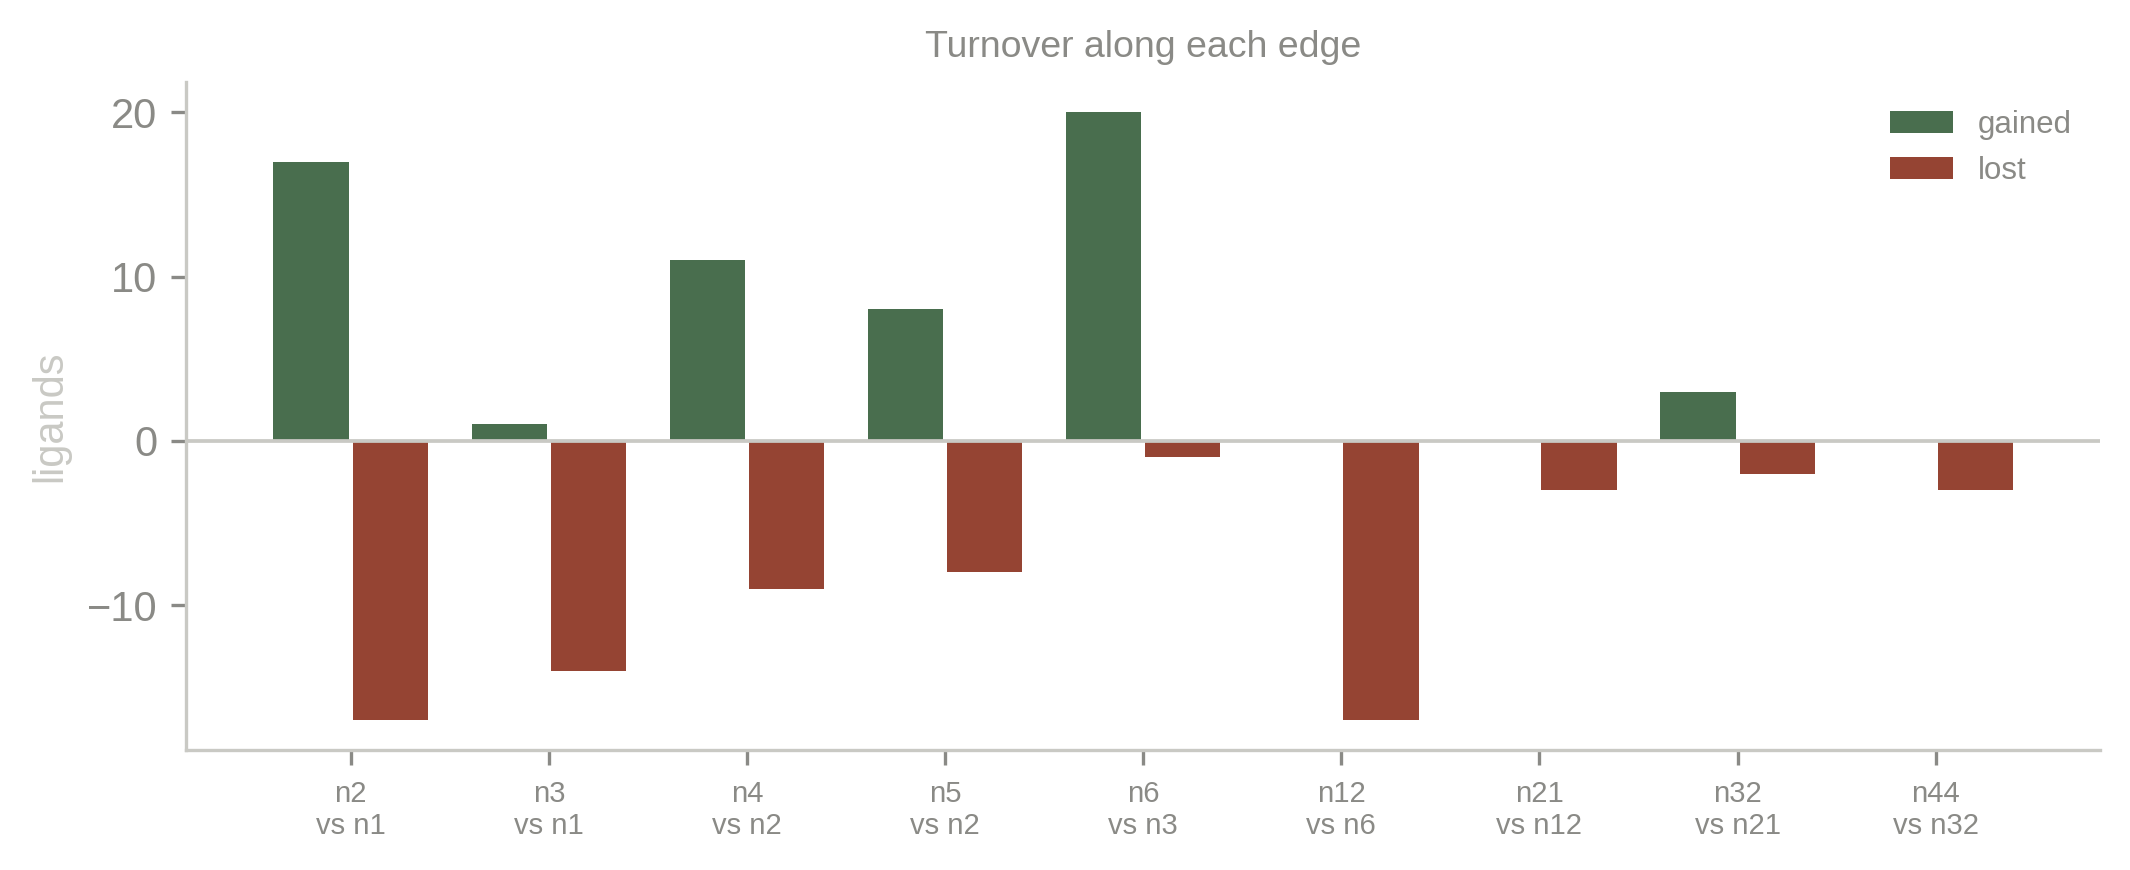

In [6]:
gl = topo.dropna(subset=["n_gained"])
print(gl[["node", "parent", "n_ligands", "n_retained", "n_gained", "n_lost"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.8, FIGSIZE[1]))
x = np.arange(len(gl))
ax.bar(x - 0.2, gl.n_gained, 0.38, color="#355E3B", label="gained", alpha=0.9)
ax.bar(x + 0.2, -gl.n_lost, 0.38, color="#8A2F1D", label="lost", alpha=0.9)
ax.axhline(0, color="#c9c9c4", lw=0.9)
ax.set_xticks(x)
ax.set_xticklabels([f"n{r.node}\nvs {r.parent.replace('node_', 'n')}" for r in gl.itertuples()],
                   fontsize=7)
ax.set_ylabel("ligands"); ax.legend(frameon=False, fontsize=7.5)
ax.set_title("Turnover along each edge", fontsize=9)
plt.tight_layout(); save_fig(fig, "05_gain_loss"); plt.show()

## Chemistry of each node's repertoire

Descriptors first, then functional-group prevalence as a heatmap across all ten.

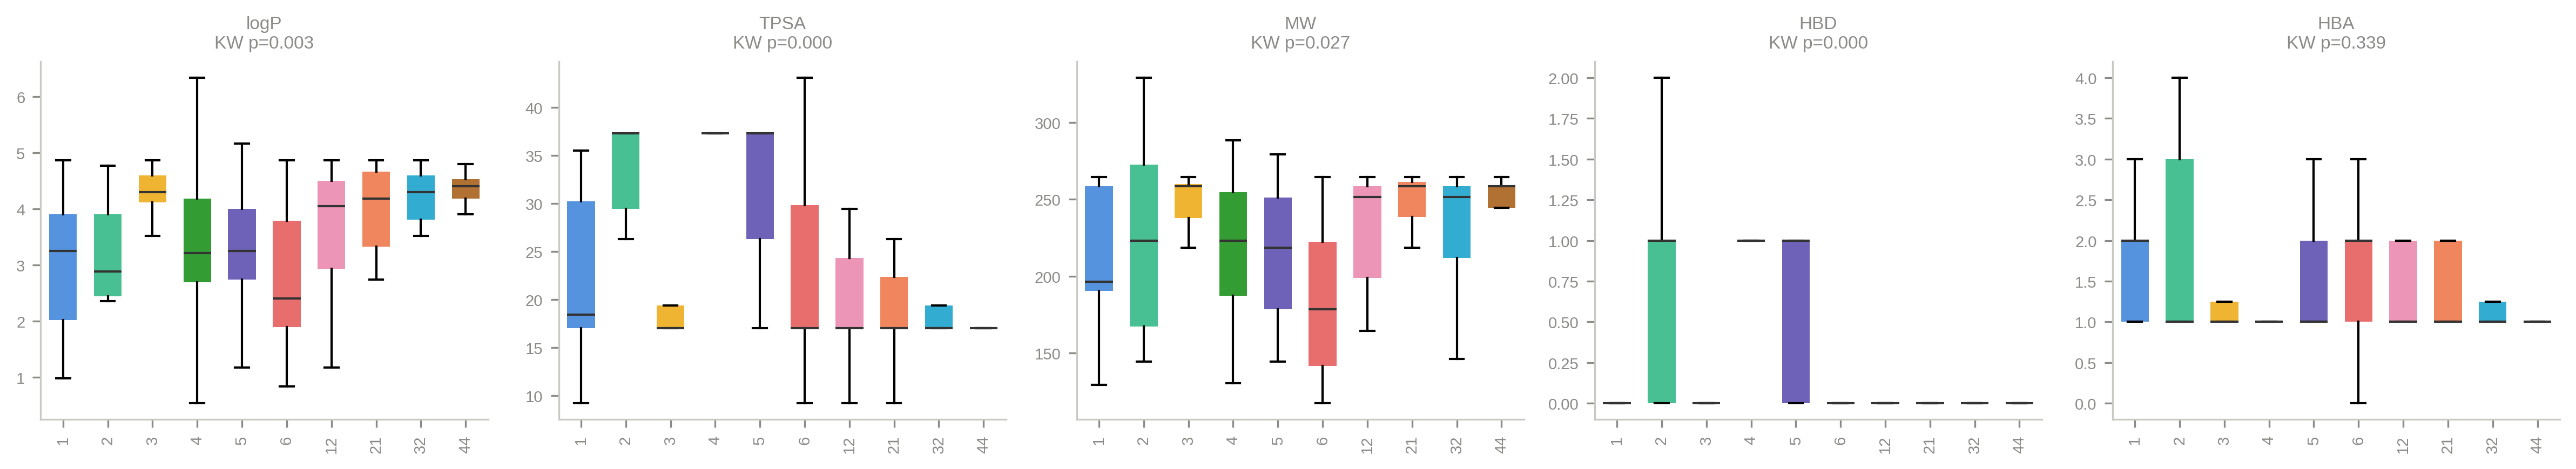

In [7]:
chem = descriptors(sorted(union_all)).merge(functional_groups(sorted(union_all)), on="SMILES")
FG_COLS = list(FG_SMARTS)

fig, axes = plt.subplots(1, len(DESCRIPTORS),
                         figsize=(FIGSIZE[0] * len(DESCRIPTORS) * 0.8, FIGSIZE[1]))
for ax, d in zip(axes, DESCRIPTORS):
    data = [chem[chem.SMILES.isin(sets[n])][d].dropna().values for n in TEN_NODES]
    bp = ax.boxplot(data, widths=0.62, patch_artist=True, showfliers=False,
                    medianprops=dict(color="#333"))
    for patch, n in zip(bp["boxes"], TEN_NODES):
        patch.set_facecolor(NCOL[n]); patch.set_alpha(0.8); patch.set_edgecolor("none")
    h, p = kruskal(*data)
    ax.set_title(f"{d}\nKW p={p:.3f}", fontsize=8)
    ax.set_xticks(range(1, len(TEN_NODES) + 1))
    ax.set_xticklabels([str(n) for n in TEN_NODES], fontsize=6, rotation=90)
    ax.tick_params(labelsize=7)
plt.tight_layout(); save_fig(fig, "05_node_descriptors"); plt.show()

                   1     2     3     4     5     6     12    21    32    44
carboxylic_acid   0.0  47.6   0.0  82.6  57.1   0.0   0.0   0.0   0.0   0.0
alcohol           4.8  14.3   0.0   4.3  14.3   3.7  10.0  14.3   0.0   0.0
aldehyde          4.8   9.5   0.0   4.3   4.8   3.7   0.0   0.0   0.0   0.0
ketone           42.9  14.3  62.5   8.7   4.8  37.0  50.0  42.9  62.5  60.0
ester            28.6   9.5  25.0   0.0  14.3  18.5  20.0  28.6  12.5  20.0
ether            52.4  23.8  37.5   4.3  28.6  37.0  50.0  57.1  25.0  40.0
amine             0.0  14.3   0.0   4.3   4.8   7.4   0.0   0.0   0.0   0.0
amide             4.8   4.8   0.0   4.3   4.8   0.0   0.0   0.0   0.0   0.0
aromatic_ring    61.9  33.3  50.0   8.7  23.8  70.4  60.0  57.1  62.5  60.0
phenol            4.8  14.3   0.0   8.7   4.8   3.7  10.0   0.0   0.0   0.0
nitrile           0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
alkene           57.1  33.3  25.0  13.0  38.1  33.3  50.0  42.9  25.0  20.0


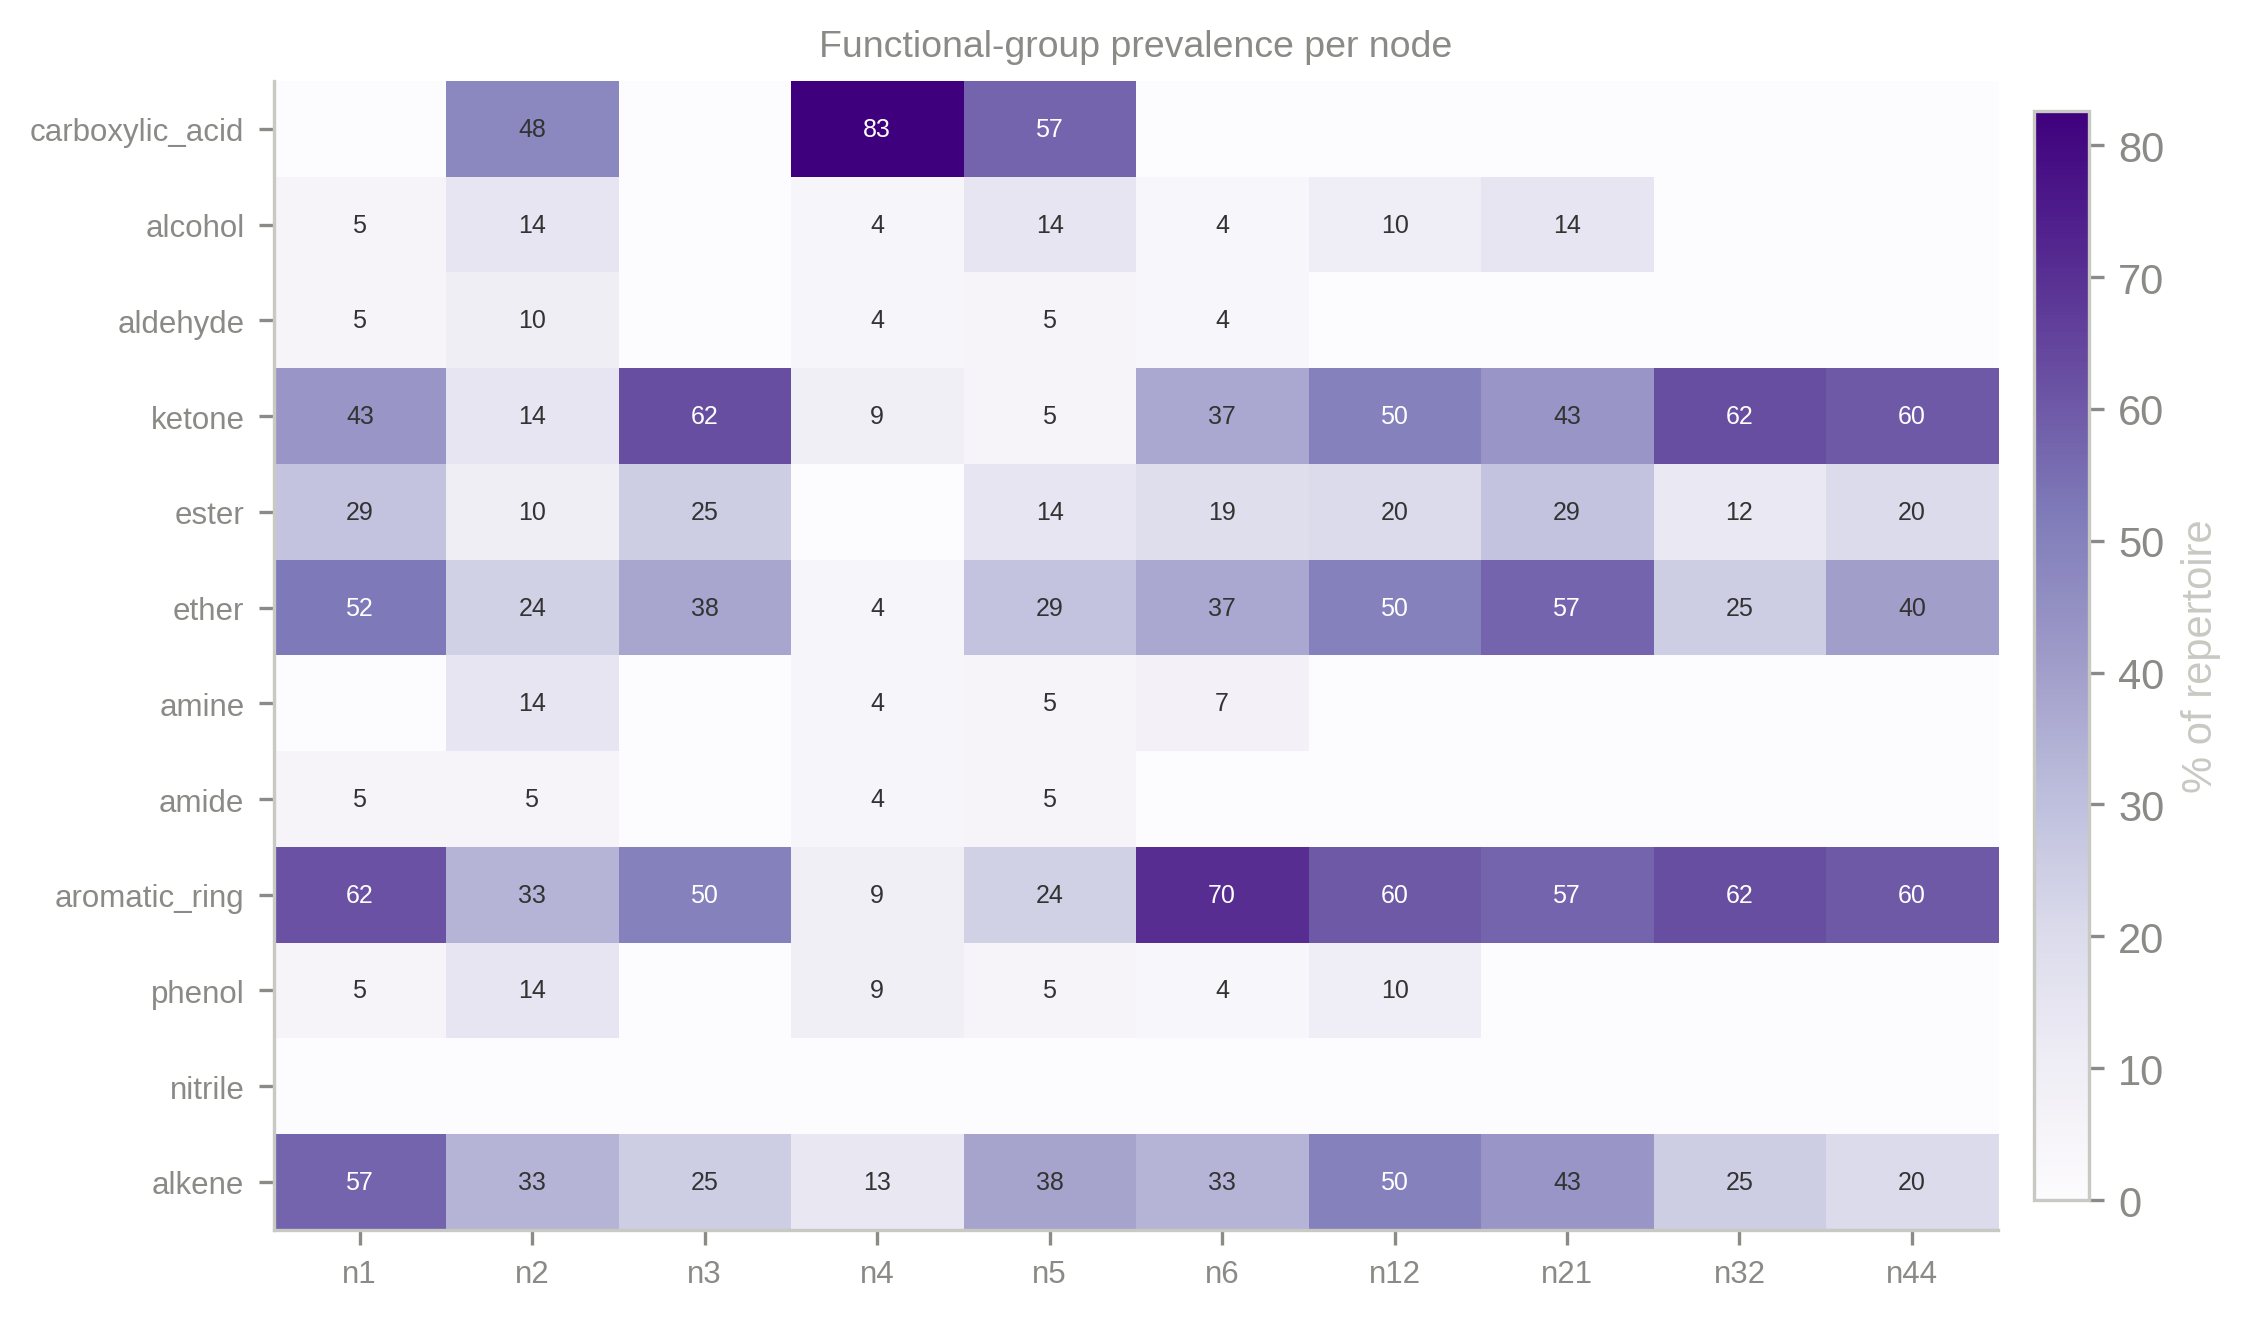

In [8]:
prev = pd.DataFrame({n: chem[chem.SMILES.isin(sets[n])][FG_COLS].mean() * 100
                     for n in TEN_NODES})
print(prev.round(1).to_string())
save_table(prev.reset_index().rename(columns={"index": "functional_group"}),
           "05_functional_groups")

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.9, FIGSIZE[1] * 1.5))
im = ax.imshow(prev.values, cmap="Purples", aspect="auto", vmin=0)
ax.set_xticks(range(len(TEN_NODES)))
ax.set_xticklabels([f"n{n}" for n in TEN_NODES], fontsize=7.5)
ax.set_yticks(range(len(prev))); ax.set_yticklabels(prev.index, fontsize=7.5)
cut = prev.values.max() * 0.6
for i in range(len(prev)):
    for j in range(len(TEN_NODES)):
        v = prev.values[i, j]
        if v >= 1:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=6,
                    color="white" if v > cut else "#333")
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="% of repertoire")
ax.set_title("Functional-group prevalence per node", fontsize=9)
plt.tight_layout(); save_fig(fig, "05_functional_groups"); plt.show()

## The two founding duplications: acids, then aromatics

`01`-`05` above treat the ten nodes symmetrically. This section isolates the two
duplications that the main figure is built around, and asks what chemistry each one
picked up.

| main-figure label | node here | event | leaves | n gained |
|---|---|---|---|---|
| **0** | `node_1` | gnathostome OR ancestor | 433 | – |
| **0 → 1** | `node_1` → `node_2` | **duplication 1**, the Class I / Class II split | 62 | 17 |
| **2 → 5** | `node_3` → `node_6` | **duplication 2**, within Class II | 370 | 20 |

`node_3`'s other child is the single receptor `9606.A6NND4`, which sits on a long branch
next to the outgroup. That is long-branch-attraction geometry rather than biology, so the
Class II duplication is read as `node_3` → `node_6` and the singleton is set aside.

`node_4` and `node_5` are the two Class I descendants (main-figure **3** and **4**); they
are carried in the plots below as the Class I continuation.


In [9]:
# The two founding duplications, and the chemistry each one gained.
anc = load_ancestral(mode="density") if THRESH is None else None
PANEL = sorted(anc.smiles_map["SMILES"].unique())

full_rep = {n: s for n, s in node_sets(TEN_NODES, threshold=THRESH).items()}
DUPS = {
    "dup1": dict(parent=1, child=2, label="dup 1  ·  0 \u2192 1  (Class I)",  col=CLASS1_COL),
    "dup2": dict(parent=3, child=6, label="dup 2  ·  2 \u2192 5  (Class II)", col=CLASS2_COL),
}
for d in DUPS.values():
    d["parent_set"] = full_rep[d["parent"]]
    d["child_set"]  = full_rep[d["child"]]
    d["gained"]     = sorted(d["child_set"] - d["parent_set"])

fg_panel = functional_groups(PANEL).set_index("SMILES")
ASR_UNIVERSE = sorted(set().union(*full_rep.values()))

rows = []
for k, d in DUPS.items():
    for bg_name, bg in [("full panel", PANEL), ("ten-node universe", ASR_UNIVERSE)]:
        bgset = [s for s in bg if s not in d["gained"]]
        for grp in ["carboxylic_acid", "aromatic_ring"]:
            a = int(fg_panel.loc[d["gained"], grp].sum()); b = len(d["gained"]) - a
            c = int(fg_panel.loc[bgset, grp].sum());       e = len(bgset) - c
            orr, pv = fisher_exact([[a, b], [c, e]])
            rows.append({"duplication": k, "background": f"{bg_name} ({len(bgset)})",
                         "group": grp, "n_gained": len(d["gained"]), "k": a,
                         "pct_gained": round(100 * a / len(d["gained"]), 1),
                         "pct_background": round(100 * c / len(bgset), 1),
                         "odds_ratio": round(orr, 2), "P": float(f"{pv:.2g}")})

dup_chem = pd.DataFrame(rows)
print(dup_chem.to_string(index=False))
save_table(dup_chem, "05_dup_chemistry")


duplication             background           group  n_gained  k  pct_gained  pct_background  odds_ratio        P
       dup1       full panel (737) carboxylic_acid        17 10        58.8             9.9       12.99 0.000002
       dup1       full panel (737)   aromatic_ring        17  5        29.4            28.9        1.03 1.000000
       dup1 ten-node universe (44) carboxylic_acid        17 10        58.8            25.0        4.29 0.018000
       dup1 ten-node universe (44)   aromatic_ring        17  5        29.4            47.7        0.46 0.250000
       dup2       full panel (734) carboxylic_acid        20  0         0.0            11.3        0.00 0.150000
       dup2       full panel (734)   aromatic_ring        20 15        75.0            27.7        7.85 0.000020
       dup2 ten-node universe (41) carboxylic_acid        20  0         0.0            51.2        0.00 0.000028
       dup2 ten-node universe (41)   aromatic_ring        20 15        75.0            26.8     

### Option A — back-to-back functional-group bars

The double dissociation stated as directly as it can be: what each duplication gained,
one duplication per side. Acids go one way, aromatics the other.


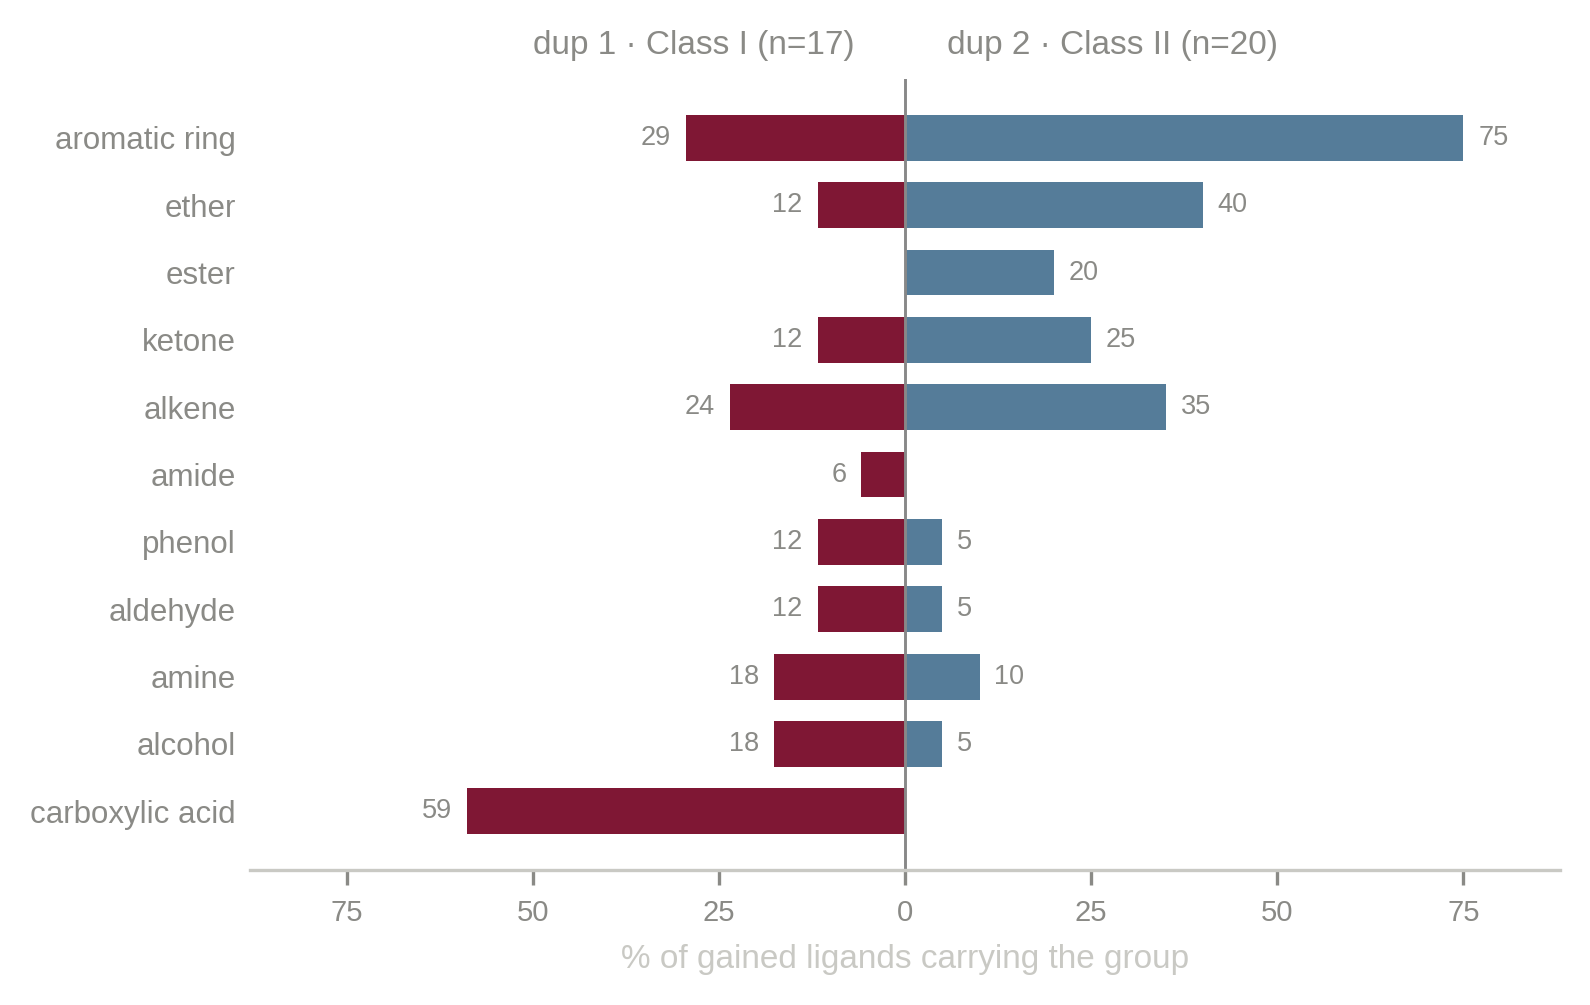

In [10]:
groups = [g for g in FG_COLS if fg_panel.loc[
    DUPS["dup1"]["gained"] + DUPS["dup2"]["gained"], g].sum() > 0]
pct = {k: fg_panel.loc[d["gained"], groups].mean() * 100 for k, d in DUPS.items()}
order = (pct["dup2"] - pct["dup1"]).sort_values().index

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.35, FIGSIZE[1] * 1.15))
y = np.arange(len(order))
ax.barh(y, -pct["dup1"][order], color=CLASS1_COL, height=0.68, linewidth=0)
ax.barh(y,  pct["dup2"][order], color=CLASS2_COL, height=0.68, linewidth=0)
ax.axvline(0, color="#888", lw=0.7)

for i, g in enumerate(order):
    if pct["dup1"][g] > 0:
        ax.text(-pct["dup1"][g] - 2, i, f"{pct['dup1'][g]:.0f}", ha="right", va="center", fontsize=6.5)
    if pct["dup2"][g] > 0:
        ax.text(pct["dup2"][g] + 2, i, f"{pct['dup2'][g]:.0f}", ha="left", va="center", fontsize=6.5)

ax.set_yticks(y); ax.set_yticklabels([g.replace("_", " ") for g in order], fontsize=7.5)
ax.set_xlim(-88, 88)
ax.set_xticks([-75, -50, -25, 0, 25, 50, 75])
ax.set_xticklabels(["75", "50", "25", "0", "25", "50", "75"], fontsize=7)
ax.set_xlabel("% of gained ligands carrying the group", fontsize=8)
ax.set_title(f"dup 1 · Class I (n={len(DUPS['dup1']['gained'])})"
             f"          dup 2 · Class II (n={len(DUPS['dup2']['gained'])})", fontsize=8)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout(); save_fig(fig, "05_optA_dup_fg_diverging"); plt.show()


### Option B — composition of each gain set

The same fact as a composition, with the ancestral repertoire as the baseline so it is
visible that neither chemistry is new to the tree — only its assignment to a clade is.


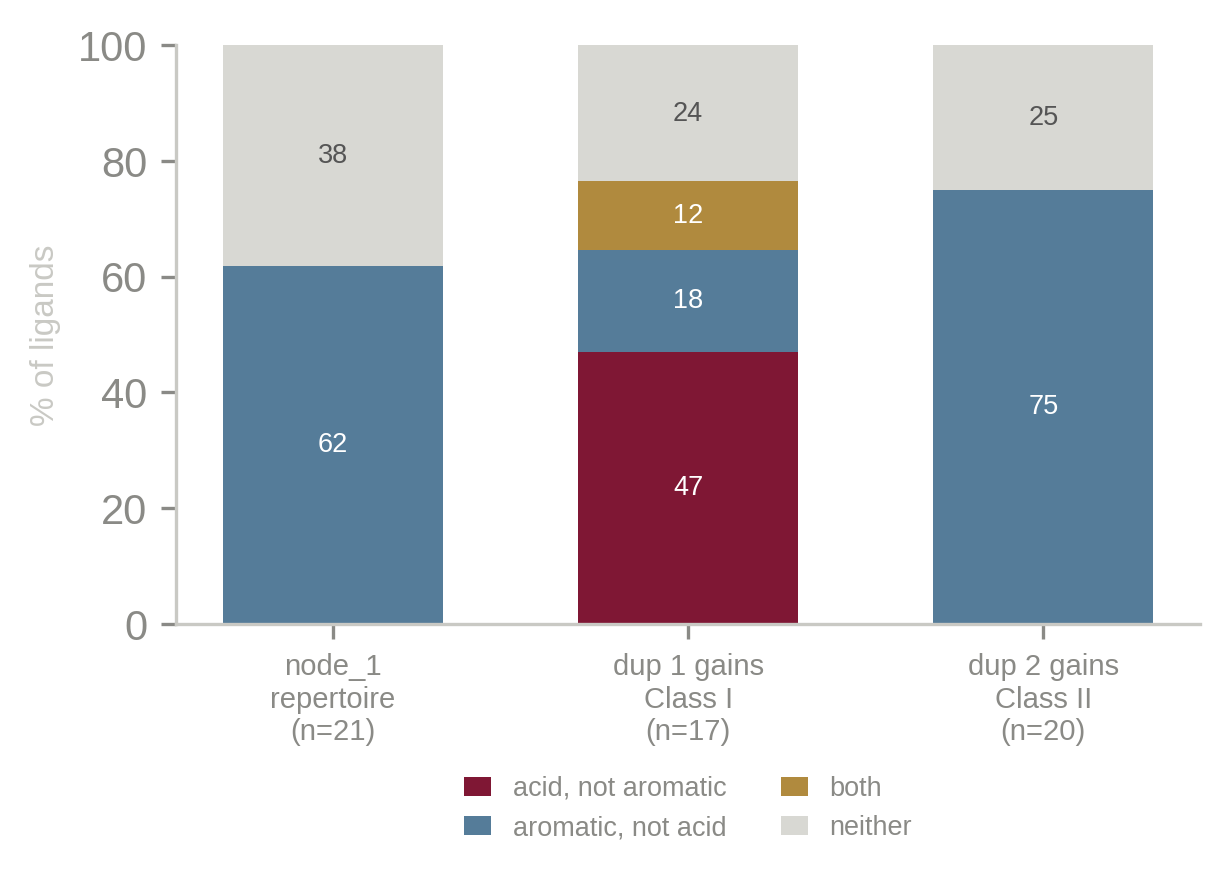

In [11]:
def compose(smis):
    sub = fg_panel.loc[smis]
    acid, arom = sub["carboxylic_acid"].astype(bool), sub["aromatic_ring"].astype(bool)
    n = len(sub)
    return np.array([(acid & ~arom).sum(), (arom & ~acid).sum(),
                     (acid & arom).sum(), (~acid & ~arom).sum()]) / n * 100

bars = {"node_1\nrepertoire\n(n=%d)" % len(DUPS["dup1"]["parent_set"]): compose(sorted(DUPS["dup1"]["parent_set"])),
        "dup 1 gains\nClass I\n(n=%d)" % len(DUPS["dup1"]["gained"]): compose(DUPS["dup1"]["gained"]),
        "dup 2 gains\nClass II\n(n=%d)" % len(DUPS["dup2"]["gained"]): compose(DUPS["dup2"]["gained"])}

cats = ["acid, not aromatic", "aromatic, not acid", "both", "neither"]
cols = [CLASS1_COL, CLASS2_COL, "#b08a3e", "#d8d8d3"]

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.05, FIGSIZE[1] * 1.05))
x = np.arange(len(bars)); bottom = np.zeros(len(bars))
vals = np.array(list(bars.values()))
for j, (c, col) in enumerate(zip(cats, cols)):
    ax.bar(x, vals[:, j], bottom=bottom, color=col, width=0.62, label=c, linewidth=0)
    for i, v in enumerate(vals[:, j]):
        if v >= 7:
            ax.text(i, bottom[i] + v / 2, f"{v:.0f}", ha="center", va="center", fontsize=6.5,
                    color="white" if j < 3 else "#555")
    bottom += vals[:, j]

ax.set_xticks(x); ax.set_xticklabels(list(bars), fontsize=7)
ax.set_ylabel("% of ligands", fontsize=8); ax.set_ylim(0, 100)
ax.legend(frameon=False, fontsize=6.5, loc="upper center",
          bbox_to_anchor=(0.5, -0.22), ncol=2, handlelength=1.0)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); save_fig(fig, "05_optB_dup_composition"); plt.show()


### Option C — per-molecule strip

Every gained molecule as one tile, so the reader sees the actual n rather than a
percentage over 17 and 20 ligands. The most honest of the four at these sample sizes.


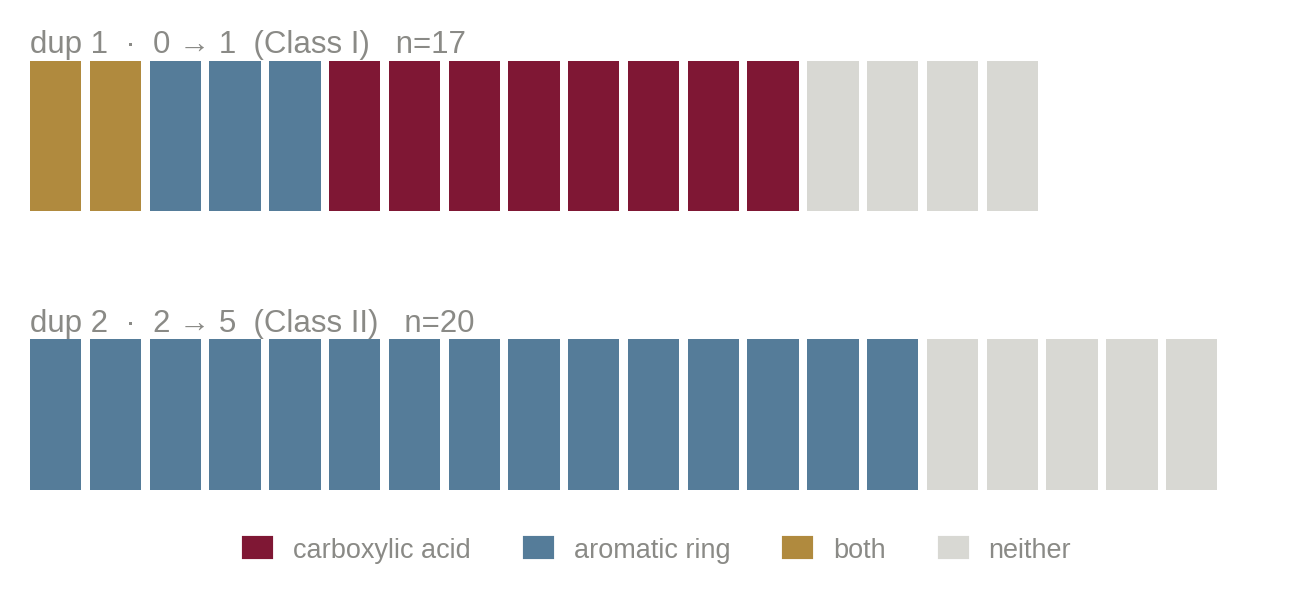

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(FIGSIZE[0] * 1.35, FIGSIZE[1] * 0.62),
                         gridspec_kw=dict(hspace=0.85))
CODE_COL = {0: "#d8d8d3", 1: CLASS1_COL, 2: CLASS2_COL, 3: "#b08a3e"}
for ax, (k, d) in zip(axes, DUPS.items()):
    sub = fg_panel.loc[d["gained"]]
    code_v = (sub["carboxylic_acid"].astype(int) + 2 * sub["aromatic_ring"].astype(int)).values
    code_v = np.sort(code_v)[::-1]
    for i, c in enumerate(code_v):
        ax.add_patch(plt.Rectangle((i, 0), 0.86, 1, color=CODE_COL[c], linewidth=0))
    ax.set_xlim(0, 21); ax.set_ylim(0, 1); ax.axis("off")
    ax.set_title(f"{d['label']}   n={len(d['gained'])}", fontsize=7.5, loc="left", pad=2)

handles = [Patch(color=CODE_COL[1], label="carboxylic acid"),
           Patch(color=CODE_COL[2], label="aromatic ring"),
           Patch(color=CODE_COL[3], label="both"),
           Patch(color=CODE_COL[0], label="neither")]
axes[-1].legend(handles=handles, frameon=False, fontsize=6.5, ncol=4,
                loc="upper center", bbox_to_anchor=(0.5, -0.15), handlelength=1.0)
save_fig(fig, "05_optC_dup_molecule_strip"); plt.show()


### Option D — the shift in descriptor space

Options A-C are one functional group at a time. This one asks where each duplication moved
the repertoire *as a whole*: represent every molecule by 13 standardised RDKit descriptors,
take the centroid of what a duplication **gained** minus the centroid of what its parent
already detected, and draw the two shift vectors.

This panel is also the orthogonality test below, so if it is used in the main figure the
supplementary null belongs with it.


In [13]:
from rdkit import Chem
from rdkit.Chem import Descriptors as _D, rdMolDescriptors as _R, Crippen as _C

D13 = ["MolWt", "LogP", "TPSA", "HBD", "HBA", "RotB", "AromaticRings", "FracCsp3",
       "HeavyAtoms", "RingCount", "MolMR", "BertzCT", "nO"]

def _desc13(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None:
        return [np.nan] * 13
    return [_D.MolWt(m), _C.MolLogP(m), _D.TPSA(m), _R.CalcNumHBD(m), _R.CalcNumHBA(m),
            _R.CalcNumRotatableBonds(m), _R.CalcNumAromaticRings(m), _R.CalcFractionCSP3(m),
            m.GetNumHeavyAtoms(), _R.CalcNumRings(m), _C.MolMR(m), _D.BertzCT(m),
            sum(1 for a in m.GetAtoms() if a.GetSymbol() == "O")]

X13 = pd.DataFrame({s: _desc13(s) for s in PANEL}).T
X13.columns = D13
Z13 = (X13 - X13.mean()) / X13.std(ddof=0)      # standardised on the full panel

def shift_vector(d):
    return Z13.loc[d["gained"]].mean().values - Z13.loc[sorted(d["parent_set"])].mean().values

v1, v2 = shift_vector(DUPS["dup1"]), shift_vector(DUPS["dup2"])

def angle(a, b):
    return np.degrees(np.arccos(np.clip(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)), -1, 1)))

OBS_ANGLE = angle(v1, v2)
print(f"angle between the two duplication shifts: {OBS_ANGLE:.1f} deg")


angle between the two duplication shifts: 96.7 deg


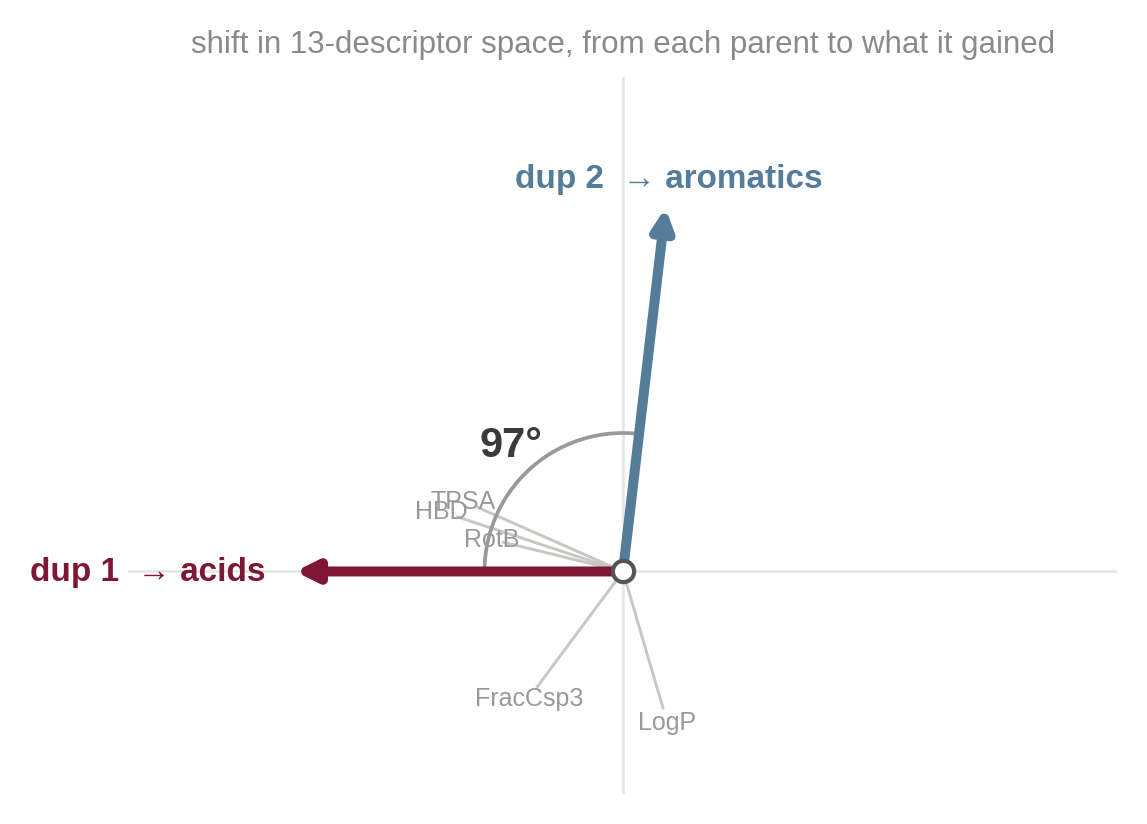

In [14]:
# The two shifts drawn from a common origin, in the plane they span, so the angle is the figure.
basis = np.linalg.qr(np.column_stack([v1, v2]))[0]
a1, a2 = v1 @ basis, v2 @ basis                     # the two shifts in that plane
lim = max(np.linalg.norm(a1), np.linalg.norm(a2)) * 1.35

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.25, FIGSIZE[1] * 0.95))

# the angle arc between them
th1, th2 = np.arctan2(a1[1], a1[0]), np.arctan2(a2[1], a2[0])
sweep = (th2 - th1 + np.pi) % (2 * np.pi) - np.pi       # signed minor arc
arc = th1 + np.linspace(0, sweep, 100)
r = lim * 0.28
ax.plot(r * np.cos(arc), r * np.sin(arc), color="#999", lw=0.9)
mid = th1 + sweep / 2
ax.text(r * 1.22 * np.cos(mid), r * 1.22 * np.sin(mid), f"{OBS_ANGLE:.0f}\u00b0",
        ha="center", va="center", fontsize=10, fontweight="bold", color="#3a3a38")

for a, col, lab in [(a1, CLASS1_COL, "dup 1  \u2192 acids"),
                    (a2, CLASS2_COL, "dup 2  \u2192 aromatics")]:
    ax.annotate("", xy=a, xytext=(0, 0), zorder=4,
                arrowprops=dict(arrowstyle="-|>", color=col, lw=2.4, shrinkA=0, shrinkB=0))
    u = a / np.linalg.norm(a)
    ax.text(a[0] + u[0] * lim * 0.06, a[1] + u[1] * lim * 0.06, lab, color=col,
            fontsize=8, fontweight="bold", va="center",
            ha="right" if u[0] < -0.3 else "left" if u[0] > 0.3 else "center")

# which descriptors drive each direction
load = pd.DataFrame({"dup1": basis[:, 0], "dup2": basis[:, 1]}, index=D13)
top = load.abs().max(axis=1).sort_values(ascending=False).head(5).index
for d in top:
    lx, ly = load.loc[d, "dup1"] * lim * 0.62, load.loc[d, "dup2"] * lim * 0.62
    ax.plot([0, lx], [0, ly], color="#c8c8c3", lw=0.7, zorder=1)
    ax.text(lx * 1.1, ly * 1.1, d, fontsize=6, color="#999", ha="center", va="center", zorder=1)

ax.scatter([0], [0], s=26, facecolor="white", edgecolor="#555", linewidth=1.0, zorder=5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim * 0.45, lim); ax.set_aspect("equal")
ax.axhline(0, color="#e5e5e0", lw=0.6, zorder=0); ax.axvline(0, color="#e5e5e0", lw=0.6, zorder=0)
ax.set_title("shift in 13-descriptor space, from each parent to what it gained", fontsize=7.5)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout(); save_fig(fig, "05_optD_shift_vectors"); plt.show()


## Is "orthogonal" a real claim? — the null

The angle above only means something against a null, because most odorants in this panel
share bulk chemistry, so *any* two shifts tend to point broadly the same way. The null draws
gain-sets of the same sizes (17 and 20) at random from the panel, keeps the same two parent
centroids, and recomputes the angle.

Two further checks: whether the result depends on which descriptors are in the set, and
whether acid and aromatic are independent enough in this panel for the dissociation to be
non-trivial.


In [15]:
rng = np.random.default_rng(0)
pan = np.array(PANEL)
n1, n2 = len(DUPS["dup1"]["gained"]), len(DUPS["dup2"]["gained"])
c1 = Z13.loc[sorted(DUPS["dup1"]["parent_set"])].mean().values
c2 = Z13.loc[sorted(DUPS["dup2"]["parent_set"])].mean().values

null = np.array([angle(Z13.loc[rng.choice(pan, n1, replace=False)].mean().values - c1,
                       Z13.loc[rng.choice(pan, n2, replace=False)].mean().values - c2)
                 for _ in range(2000)])
p_emp = float((np.abs(null - 90) <= abs(OBS_ANGLE - 90)).mean())
print(f"observed            {OBS_ANGLE:.1f} deg")
print(f"null median         {np.median(null):.1f} deg   IQR {np.percentile(null,25):.0f}-{np.percentile(null,75):.0f}")
print(f"as close to 90 deg  {int(p_emp*2000)} / 2000   (p = {p_emp:.4f})")

loo = [angle(np.delete(v1, i), np.delete(v2, i)) for i in range(13)]
print(f"leave-one-descriptor-out  {min(loo):.1f}-{max(loo):.1f} deg")

phi = np.corrcoef(fg_panel["carboxylic_acid"], fg_panel["aromatic_ring"])[0, 1]
ac, ar = fg_panel["carboxylic_acid"].astype(bool), fg_panel["aromatic_ring"].astype(bool)
print(f"phi(acid, aromatic) over the panel = {phi:+.3f}   "
      f"{100*ar[ac].mean():.0f}% of acids aromatic, {100*ac[ar].mean():.0f}% of aromatics acids")

save_table(pd.DataFrame({"observed_angle": [round(OBS_ANGLE, 1)],
                         "null_median": [round(float(np.median(null)), 1)],
                         "null_q25": [round(float(np.percentile(null, 25)), 1)],
                         "null_q75": [round(float(np.percentile(null, 75)), 1)],
                         "p_empirical": [p_emp], "n_draws": [2000],
                         "loo_min": [round(min(loo), 1)], "loo_max": [round(max(loo), 1)],
                         "phi_acid_aromatic": [round(float(phi), 3)]}),
           "05_orthogonality")


observed            96.7 deg
null median         33.3 deg   IQR 28-40
as close to 90 deg  0 / 2000   (p = 0.0000)
leave-one-descriptor-out  90.2-102.5 deg
phi(acid, aromatic) over the panel = -0.103   16% of acids aromatic, 6% of aromatics acids


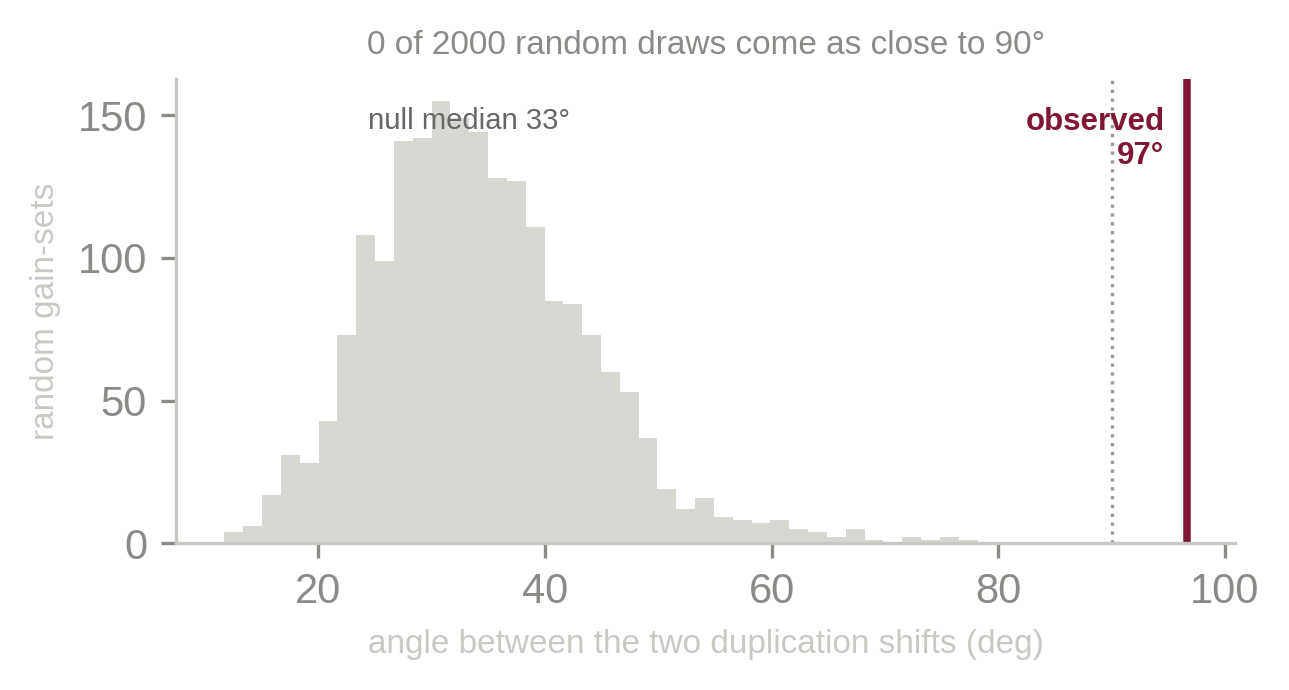

In [16]:
fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.1, FIGSIZE[1] * 0.8))
ax.hist(null, bins=40, color="#d8d8d3", linewidth=0)
ax.axvline(90, color="#999", lw=0.8, ls=":")
ax.axvline(OBS_ANGLE, color="#7f1734", lw=1.8)
ax.text(OBS_ANGLE - 2, ax.get_ylim()[1] * 0.94, f"observed\n{OBS_ANGLE:.0f}\u00b0",
        ha="right", va="top", fontsize=7.5, color="#7f1734", fontweight="bold")
ax.text(float(np.median(null)), ax.get_ylim()[1] * 0.94,
        f"null median {np.median(null):.0f}\u00b0", ha="center", va="top", fontsize=7, color="#666")
ax.set_xlabel("angle between the two duplication shifts (deg)", fontsize=8)
ax.set_ylabel("random gain-sets", fontsize=8)
ax.set_title(f"0 of 2000 random draws come as close to 90\u00b0", fontsize=8)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); save_fig(fig, "05_orthogonality_null"); plt.show()


### Every branch out of the two duplication nodes

`DUPS` above carries only the two branches that show chemistry. A duplication is a **node**
with **two** daughter branches, so both are tabulated here — otherwise "dup 1" reads as one
edge when it is two, and the asymmetry between them is the point.

Repertoires come from the density grid rather than `node_sets`, because one daughter of
node 2 is an extant tip and tips are not in the ASR node table.


In [17]:
_bin, _prob, *_ = density_grid()
_id2smi = anc.smiles_map.drop_duplicates("SML_ID").set_index("SML_ID")["SMILES"]

def grid_rep(name):
    """Ligand set of any row of the density grid — internal node or extant tip."""
    row = _bin.loc[name]
    return {_id2smi[i] for i in _bin.columns[row.values.astype(bool)] if i in _id2smi.index}

tree, index = asr_tree()
BRANCHES = []
for dup, parent in [("duplication 1", "node_1"), ("duplication 2", "node_3")]:
    P = grid_rep(parent)
    for child in [c.name for c in index[parent].children]:
        C = grid_rep(child)
        BRANCHES.append({"duplication": dup, "parent": parent, "child": child,
                         "fig_label": {"node_1": "0", "node_2": "1", "node_3": "2",
                                       "node_6": "5"}.get(child, "—"),
                         "parent_ligands": len(P), "child_ligands": len(C),
                         "retained": len(P & C), "gained": len(C - P), "lost": len(P - C)})

branches = pd.DataFrame(BRANCHES)
print(branches.to_string(index=False))
save_table(branches, "05_duplication_branches")


  duplication parent       child fig_label  parent_ligands  child_ligands  retained  gained  lost
duplication 1 node_1      node_2         1              21             21         4      17    17
duplication 1 node_1      node_3         2              21              8         7       1    14
duplication 2 node_3 9606.A6NND4         —               8              4         4       0     4
duplication 2 node_3      node_6         5               8             27         7      20     1


### The two blocks of main Table 1

Standing repertoire and chemistry per node, then the combinatorial code per stage. These are
the numbers the manuscript table is built from, so they are computed here rather than by hand.


In [18]:
FIG_LABEL = {"node_1": "0", "node_2": "1", "node_3": "2",
             "node_4": "3", "node_5": "4", "node_6": "5"}
leaf_class = pd.read_csv(CLASSES).set_index("leaf_id")["OR_class"].to_dict()

rows = []
for repo, fl in FIG_LABEL.items():
    nd = index[repo]
    leaves = [leaf_class[l.name] for l in nd.leaves() if l.name in leaf_class]
    share_i = leaves.count("Class_I") / len(leaves)
    bound = grid_rep(repo)
    parent = nd.up.name if nd.up else None
    pb = grid_rep(parent) if parent in _bin.index else None
    sub = fg_panel.loc[sorted(bound)]
    rows.append({
        "node_fig": fl, "node_id": repo,
        "OR_class": "Class I" if share_i >= 0.9 else "Class II" if share_i <= 0.1 else "root (mixed)",
        "human_ORs": len(leaves), "ligands": len(bound),
        "retained": len(bound & pb) if pb is not None else None,
        "gained":   len(bound - pb) if pb is not None else None,
        "lost":     len(pb - bound) if pb is not None else None,
        "pct_carboxylic_acid": round(100 * sub["carboxylic_acid"].mean()),
        "pct_aromatic_ring":   round(100 * sub["aromatic_ring"].mean())})

table1a = pd.DataFrame(rows)
print(table1a.to_string(index=False))
save_table(table1a, "05_table1_nodes")


node_fig node_id     OR_class  human_ORs  ligands  retained  gained  lost  pct_carboxylic_acid  pct_aromatic_ring
       0  node_1 root (mixed)        433       21       NaN     NaN   NaN                    0                 62
       1  node_2      Class I         62       21       4.0    17.0  17.0                   48                 33
       2  node_3     Class II        371        8       7.0     1.0  14.0                    0                 50
       3  node_4      Class I         55       23      12.0    11.0   9.0                   83                  9
       4  node_5      Class I          7       21      13.0     8.0   8.0                   57                 24
       5  node_6     Class II        370       27       7.0    20.0   1.0                    0                 70


In [19]:
from collections import Counter

STAGES = {"S0": ["node_1"], "S1": ["node_2", "node_3"], "S2": ["node_4", "node_5", "node_6"]}
rows = []
for stage, members in STAGES.items():
    counts = Counter()
    for n in members:
        for smi in grid_rep(n):
            counts[smi] += 1
    encoded = len(counts)
    single = sum(1 for c in counts.values() if c == 1)
    rows.append({"stage": stage, "n_receptors": len(members),
                 "nodes_fig": ", ".join(FIG_LABEL[n] for n in members),
                 "encoded": encoded, "single_detector": single,
                 "combinatorial": encoded - single,
                 "pct_combinatorial": round(100 * (encoded - single) / encoded, 1)})

table1b = pd.DataFrame(rows)
print(table1b.to_string(index=False))
save_table(table1b, "05_table1_stages")


stage  n_receptors nodes_fig  encoded  single_detector  combinatorial  pct_combinatorial
   S0            1         0       21               21              0                0.0
   S1            2      1, 2       27               25              2                7.4
   S2            3   3, 4, 5       53               36             17               32.1


### Orthogonality: the statistic in full, and whether the geometry carries it

Everything the methods text needs to state the statistic exactly: the vector lengths, the
cosine the angle comes from, and the check that the two-dimensional panel above is the true
plane of the two vectors rather than a lossy projection.


In [20]:
print(f"|v1| = {np.linalg.norm(v1):.3f}   |v2| = {np.linalg.norm(v2):.3f}   (panel SD units)")
cos_theta = v1 @ v2 / (np.linalg.norm(v1) * np.linalg.norm(v2))
print(f"cosine similarity = {cos_theta:+.4f}   ->   angle = {OBS_ANGLE:.2f} deg")
print(f"null: median {np.median(null):.1f}   IQR {np.percentile(null,25):.1f}-{np.percentile(null,75):.1f}"
      f"   min {null.min():.1f}   max {null.max():.1f}")
print(f"test statistic |theta - 90| = {abs(OBS_ANGLE - 90):.2f} deg"
      f"  ->  null draws inside [{90-abs(OBS_ANGLE-90):.1f}, {90+abs(OBS_ANGLE-90):.1f}]"
      f" = {int((np.abs(null - 90) <= abs(OBS_ANGLE - 90)).sum())} / {len(null)}")

# the 2-D panel plots v1, v2 in the QR basis of [v1 v2] -- that basis spans exactly their
# plane, so the drawn angle must equal the 13-D angle. Verified rather than asserted.
_B = np.linalg.qr(np.column_stack([v1, v2]))[0]
print(f"\nangle in the drawn plane = {angle(v1 @ _B, v2 @ _B):.2f} deg"
      f"  (13-D angle {OBS_ANGLE:.2f} -> the panel is exact, not a projection)")


|v1| = 3.337   |v2| = 3.729   (panel SD units)
cosine similarity = -0.1162   ->   angle = 96.67 deg
null: median 33.3   IQR 27.8-39.9   min 11.7   max 78.2
test statistic |theta - 90| = 6.67 deg  ->  null draws inside [83.3, 96.7] = 0 / 2000

angle in the drawn plane = 96.67 deg  (13-D angle 96.67 -> the panel is exact, not a projection)


In [21]:
# Does the result depend on descriptor redundancy, or on the choice of reference?
corr = np.corrcoef(Z13[D13].values.T)
off = corr[np.triu_indices(len(D13), 1)]
print(f"descriptor correlations: max |r| = {np.abs(off).max():.2f}, mean |r| = {np.abs(off).mean():.2f}")

W = np.linalg.inv(np.linalg.cholesky(corr))      # whitening: decorrelate the 13 axes
c1 = Z13.loc[sorted(DUPS["dup1"]["parent_set"])].mean().values
c2 = Z13.loc[sorted(DUPS["dup2"]["parent_set"])].mean().values

rng = np.random.default_rng(0)
null_w = np.array([angle(W @ (Z13.loc[rng.choice(pan, n1, replace=False)].mean().values - c1),
                         W @ (Z13.loc[rng.choice(pan, n2, replace=False)].mean().values - c2))
                   for _ in range(2000)])
obs_w = angle(W @ v1, W @ v2)

variants = pd.DataFrame([
    {"variant": "as specified (Euclidean, parent-referenced)", "angle": round(OBS_ANGLE, 1),
     "null_median": round(float(np.median(null)), 1), "null_max": round(float(null.max()), 1),
     "draws_ge_observed": int((null >= OBS_ANGLE).sum())},
    {"variant": "whitened (Mahalanobis, panel correlation)", "angle": round(obs_w, 1),
     "null_median": round(float(np.median(null_w)), 1), "null_max": round(float(null_w.max()), 1),
     "draws_ge_observed": int((null_w >= obs_w).sum())},
    {"variant": "both branches referenced to node 0", "angle": round(
        angle(v1, Z13.loc[DUPS["dup2"]["gained"]].mean().values - c1), 1),
     "null_median": None, "null_max": None, "draws_ge_observed": None},
    {"variant": "raw gain centroids, no parent subtracted", "angle": round(
        angle(Z13.loc[DUPS["dup1"]["gained"]].mean().values,
              Z13.loc[DUPS["dup2"]["gained"]].mean().values), 1),
     "null_median": None, "null_max": None, "draws_ge_observed": None},
])
print(variants.to_string(index=False))
print("\nThe last two are different questions and each would need its own null;"
      "\nthe pre-specified definition is the parent-referenced one on the first row.")
save_table(variants, "05_orthogonality_variants")


descriptor correlations: max |r| = 0.98, mean |r| = 0.38


                                    variant  angle  null_median  null_max  draws_ge_observed
as specified (Euclidean, parent-referenced)   96.7         33.3      78.2                0.0
  whitened (Mahalanobis, panel correlation)   88.5         45.6      73.9                0.0
         both branches referenced to node 0  108.0          NaN       NaN                NaN
   raw gain centroids, no parent subtracted   72.8          NaN       NaN                NaN

The last two are different questions and each would need its own null;
the pre-specified definition is the parent-referenced one on the first row.


## Deciding what goes where

Every candidate result from the ancestral analysis on one chart, so placement is argued from
evidence rather than from how good a panel looks. Two axes:

- **x — strength**, as &minus;log10 of the result's own P value (enrichment tests, the
  orthogonality permutation, the stage contrast). Capped at 8 so one very small P does not
  flatten the rest.
- **y — how much of the claim survives its control**, scored 0-3: does an explicit null exist,
  does the result pass it, and is it robust to the threshold / descriptor / background choice.

Marker size is the sample the claim rests on. Colour is the recommended destination. A result
that is strong but fails its control belongs in the supplement *with* its null, not in the main
figure — that is the whole point of plotting the two axes together rather than ranking by P.


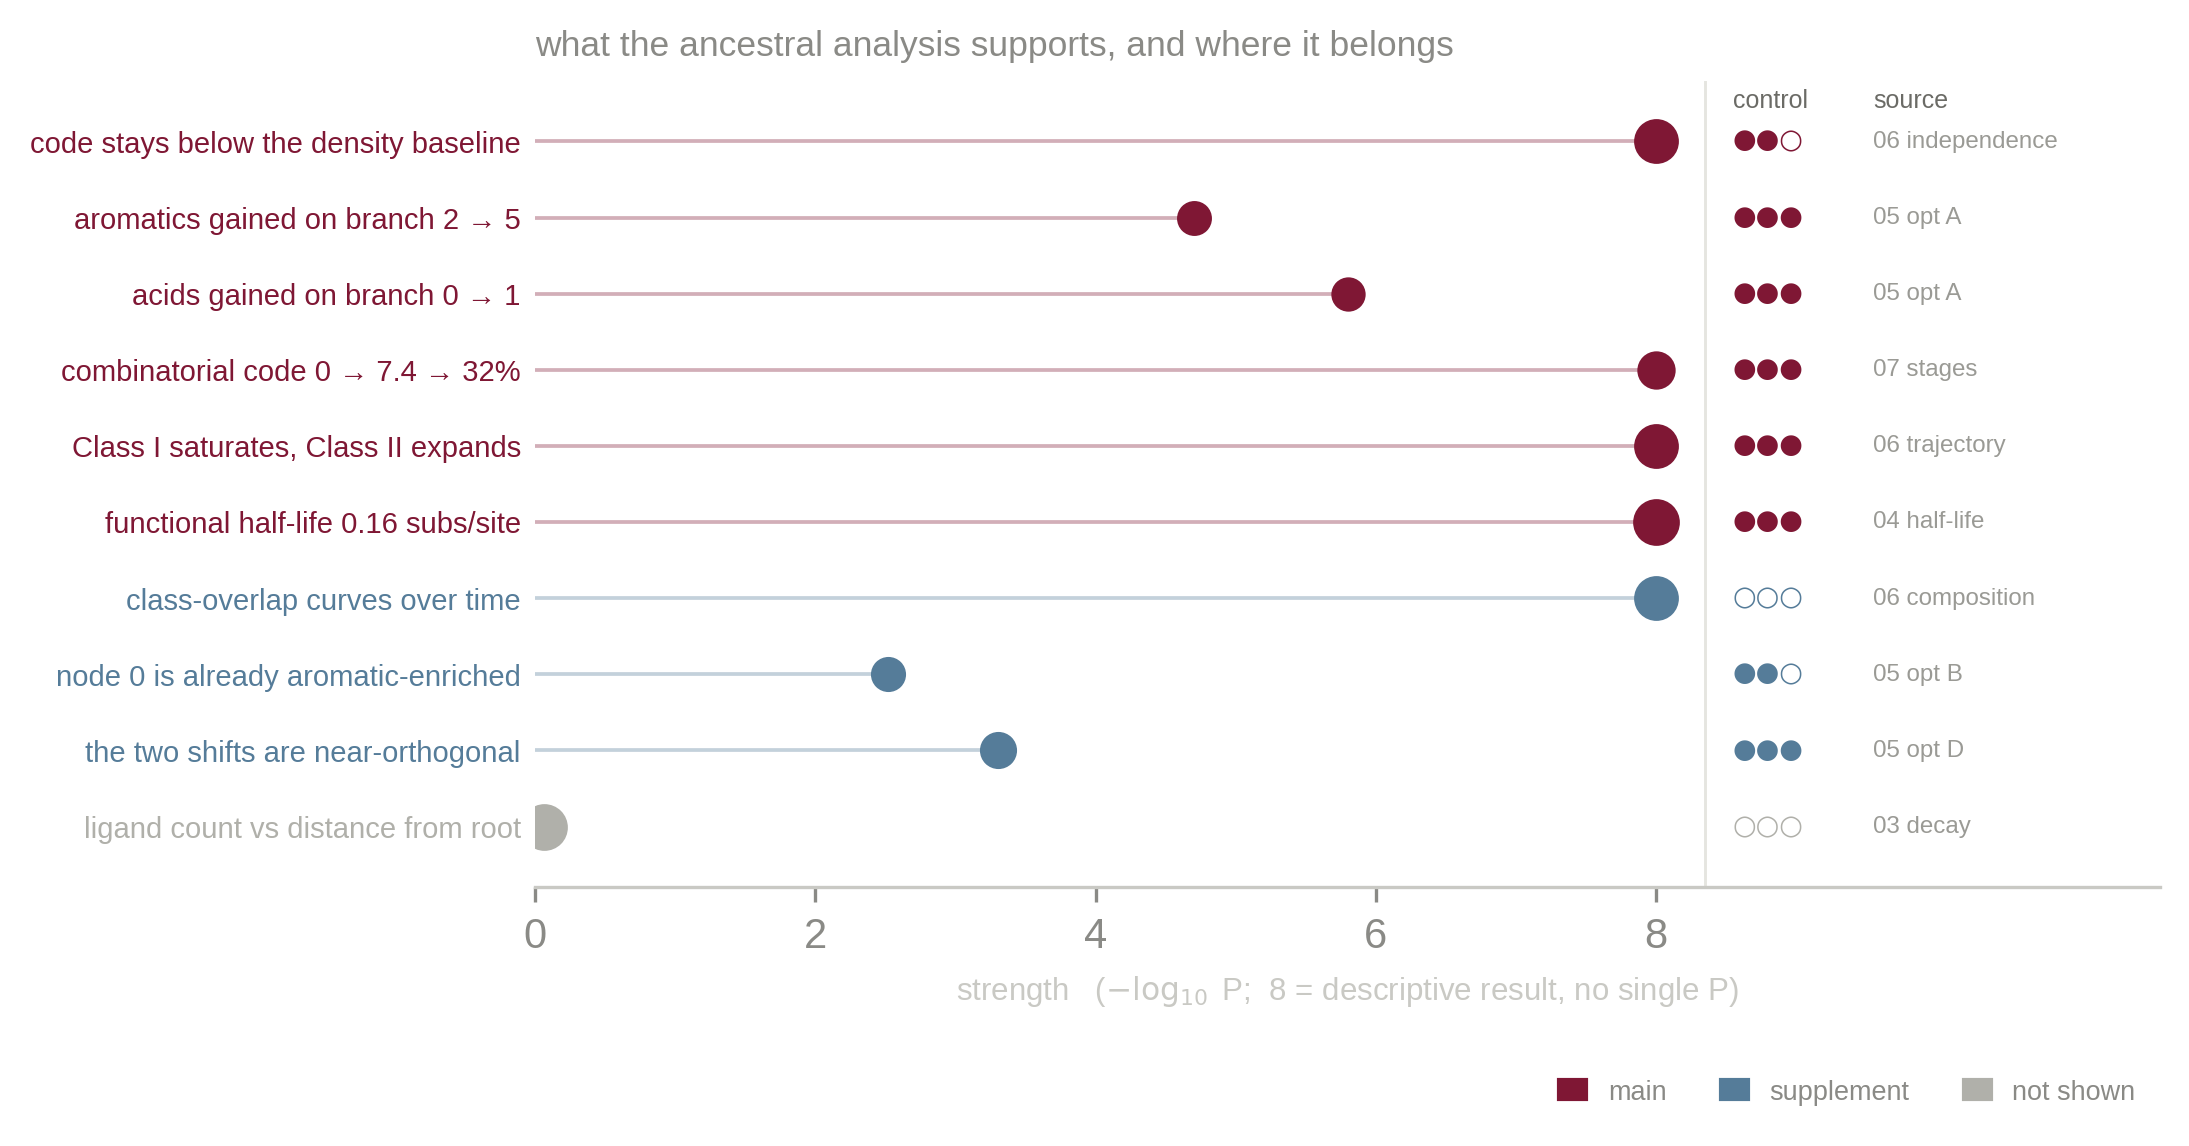

In [22]:
# One row per candidate result. `survives` and `where` are judgements, recorded explicitly
# so they can be argued with; every other column is computed above or in 03/04/06/07.
CAND = pd.DataFrame([
    # label                                    n   neglogP survives where        source
    ("acids gained on branch 0 \u2192 1",          17,  5.80,  3, "main",       "05 opt A"),
    ("aromatics gained on branch 2 \u2192 5",      20,  4.70,  3, "main",       "05 opt A"),
    ("combinatorial code 0 \u2192 7.4 \u2192 32%",     53,  None,  3, "main",       "07 stages"),
    ("Class I saturates, Class II expands",    433,  None,  3, "main",       "06 trajectory"),
    ("functional half-life 0.16 subs/site",    861,  None,  3, "main",       "04 half-life"),
    ("code stays below the density baseline",  433,  None,  2, "main",       "06 independence"),
    ("the two shifts are near-orthogonal",      37,  3.30,  3, "supplement",  "05 opt D"),
    ("node 0 is already aromatic-enriched",     21,  2.52,  2, "supplement",  "05 opt B"),
    ("class-overlap curves over time",         433,  None,  0, "supplement",  "06 composition"),
    ("ligand count vs distance from root",     865,  0.06,  0, "not shown",   "03 decay"),
], columns=["label", "n", "neglogP", "survives", "where", "source"])

WHERE_COL = {"main": CLASS1_COL, "supplement": CLASS2_COL, "not shown": "#b0b0aa"}
CAND["x"] = CAND["neglogP"].fillna(8.0).clip(upper=8.0)
CAND = CAND.sort_values(["where", "survives", "x"],
                        key=lambda s: s.map({"main": 0, "supplement": 1, "not shown": 2})
                        if s.name == "where" else s).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.85, FIGSIZE[1] * 1.35))
yy = np.arange(len(CAND))[::-1]
for (_, r), ypos in zip(CAND.iterrows(), yy):
    col = WHERE_COL[r["where"]]
    ax.plot([0, r["x"]], [ypos, ypos], color=col, lw=0.9, alpha=0.35, zorder=1)
    ax.scatter(r["x"], ypos, s=26 + 34 * np.log10(r["n"]), color=col,
               linewidth=0, zorder=3)
    ax.text(8.55, ypos, "\u25cf" * r["survives"] + "\u25cb" * (3 - r["survives"]),
            fontsize=6.5, color=col, va="center", ha="left", family="DejaVu Sans")
    ax.text(9.55, ypos, r["source"], fontsize=5.8, color="#9a9a95", va="center")

ax.set_yticks(yy); ax.set_yticklabels(CAND["label"], fontsize=7)
for tick, w in zip(ax.get_yticklabels(), CAND["where"]):
    tick.set_color(WHERE_COL[w])
ax.set_xlim(0, 11.6); ax.set_ylim(-0.8, len(CAND) - 0.2)
ax.set_xticks([0, 2, 4, 6, 8])
ax.set_xlabel("strength   ($-\\log_{10}$ P;  8 = descriptive result, no single P)", fontsize=7.5)
ax.text(8.55, len(CAND) - 0.55, "control", fontsize=6, color="#6b6b66")
ax.text(9.55, len(CAND) - 0.55, "source", fontsize=6, color="#6b6b66")
ax.axvline(8.35, color="#e5e5e0", lw=0.7)

handles = [Patch(color=WHERE_COL[w], label=w) for w in ["main", "supplement", "not shown"]]
ax.legend(handles=handles, frameon=False, fontsize=6.5, loc="lower right",
          bbox_to_anchor=(1.0, -0.30), ncol=3, handlelength=1.0)
ax.set_title("what the ancestral analysis supports, and where it belongs", fontsize=8.5, loc="left")
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout(); save_fig(fig, "05_placement_triage"); plt.show()

save_table(CAND.drop(columns="x"), "05_placement_triage")


### Option E — the same result as a PCA of odorant chemical space

Option D is exact but non-standard: readers have to decode a 13-dimensional angle. A PCA of
the odorant panel with the two gain sets drawn on it is the familiar version of the same
picture, and for most audiences the more straightforward one.

**One honesty check has to accompany it.** A PCA plane is a *projection*, so unlike option D
the angle a reader measures off the page is not the statistic. The next cell reports how much
of each shift the first two components actually capture, and what the projected angle would
look like, so the caption can state both.


In [23]:
# PCA of the 754-odorant panel in the same 13 standardised descriptors.
Zc = Z13[D13].values - Z13[D13].values.mean(0)
_U, _S, _Vt = np.linalg.svd(Zc, full_matrices=False)
evr = _S ** 2 / np.sum(_S ** 2)
pcs = Zc @ _Vt[:2].T
pc = pd.DataFrame(pcs, index=Z13.index, columns=["PC1", "PC2"])

cap = {k: 100 * np.linalg.norm(_Vt[:2] @ v) / np.linalg.norm(v)
       for k, v in [("dup1", v1), ("dup2", v2)]}
proj_angle = angle(_Vt[:2] @ v1, _Vt[:2] @ v2)
print(f"PC1 {100*evr[0]:.0f}%   PC2 {100*evr[1]:.0f}%   (together {100*(evr[0]+evr[1]):.0f}%)")
print(f"shift captured by the PC1-PC2 plane:  dup1 {cap['dup1']:.0f}%   dup2 {cap['dup2']:.0f}%")
print(f"angle a reader would measure on this plot = {proj_angle:.1f} deg"
      f"   (true 13-D angle {OBS_ANGLE:.1f} deg)")
for i, lab in [(0, "PC1"), (1, "PC2")]:
    top = sorted(zip(D13, _Vt[i]), key=lambda t: -abs(t[1]))[:4]
    print(f"  {lab} loads on: " + ", ".join(f"{d} {w:+.2f}" for d, w in top))


PC1 42%   PC2 21%   (together 64%)
shift captured by the PC1-PC2 plane:  dup1 67%   dup2 88%
angle a reader would measure on this plot = 106.0 deg   (true 13-D angle 96.7 deg)
  PC1 loads on: HeavyAtoms +0.39, MolWt +0.39, BertzCT +0.37, MolMR +0.34
  PC2 loads on: LogP -0.55, MolMR -0.34, FracCsp3 -0.30, HBD +0.28


### Two cross-checks the PCA panel needs beside it

**PERMANOVA** is the test most readers of an ecology or evolution journal will expect for
"do these two sets differ in multivariate composition". **Removing acid and aromatic
character** answers the obvious objection that the geometry is only the two functional-group
enrichments restated.


In [24]:
from scipy.spatial.distance import pdist, squareform
from scipy.stats import levene

g1s, g2s = DUPS["dup1"]["gained"], DUPS["dup2"]["gained"]
M = Z13.loc[g1s + g2s, D13].values
lab = np.array([0] * len(g1s) + [1] * len(g2s))
Dm = squareform(pdist(M))

def pseudo_f(dist, labels):
    n = len(labels)
    sst = (dist ** 2).sum() / (2 * n)
    ssw = sum((dist[np.ix_(np.where(labels == k)[0], np.where(labels == k)[0])] ** 2).sum()
              / (2 * (labels == k).sum()) for k in np.unique(labels))
    a = len(np.unique(labels))
    return ((sst - ssw) / (a - 1)) / (ssw / (n - a)), 1 - ssw / sst

F_obs, R2 = pseudo_f(Dm, lab)
_rng = np.random.default_rng(0)
F_null = np.array([pseudo_f(Dm, _rng.permutation(lab))[0] for _ in range(4999)])
permanova_p = (1 + (F_null >= F_obs).sum()) / (1 + len(F_null))
print(f"PERMANOVA  pseudo-F = {F_obs:.2f}   R2 = {R2:.3f}   P = {permanova_p:.4f}  (4999 permutations)")

d_own = [np.linalg.norm(M[lab == k] - M[lab == k].mean(0), axis=1) for k in (0, 1)]
print(f"  dispersion (mean distance to own centroid): {d_own[0].mean():.2f} vs {d_own[1].mean():.2f}, "
      f"Levene P = {levene(*d_own).pvalue:.3f}  -> a location difference, not a spread difference")

# does the geometry survive stripping acid and aromatic character out of the descriptors?
A = np.column_stack([np.ones(len(PANEL)),
                     fg_panel.loc[PANEL, "carboxylic_acid"].values,
                     fg_panel.loc[PANEL, "aromatic_ring"].values]).astype(float)
Zp = pd.DataFrame(Z13[D13].values - A @ np.linalg.lstsq(A, Z13[D13].values, rcond=None)[0],
                  index=Z13.index, columns=D13)
sh = lambda Zm, k: (Zm.loc[DUPS[k]["gained"]].mean().values
                    - Zm.loc[sorted(DUPS[k]["parent_set"])].mean().values)
obs_p = angle(sh(Zp, "dup1"), sh(Zp, "dup2"))
c1p, c2p = (Zp.loc[sorted(DUPS[k]["parent_set"])].mean().values for k in ("dup1", "dup2"))
null_p = np.array([angle(Zp.loc[_rng.choice(pan, n1, replace=False)].mean().values - c1p,
                         Zp.loc[_rng.choice(pan, n2, replace=False)].mean().values - c2p)
                   for _ in range(2000)])
print(f"\nangle with acid + aromatic regressed out of every descriptor = {obs_p:.1f} deg")
print(f"  its null: median {np.median(null_p):.1f}, max {null_p.max():.1f}, "
      f"draws >= observed = {int((null_p >= obs_p).sum())}/2000")
print("  -> the separation is broader than the two functional groups the Fisher tests name.")

save_table(pd.DataFrame([
    {"check": "PERMANOVA (13 descriptors)", "statistic": f"pseudo-F = {F_obs:.2f}",
     "value": round(R2, 3), "P": round(permanova_p, 4)},
    {"check": "dispersion (Levene)", "statistic": "mean dist to centroid",
     "value": round(float(d_own[0].mean() - d_own[1].mean()), 2),
     "P": round(float(levene(*d_own).pvalue), 3)},
    {"check": "angle, acid+aromatic regressed out", "statistic": "degrees",
     "value": round(obs_p, 1), "P": round(float((null_p >= obs_p).mean()), 4)},
    {"check": "PC1-PC2 shift fidelity", "statistic": "% of shift captured",
     "value": f"dup1 {cap['dup1']:.0f}%, dup2 {cap['dup2']:.0f}%", "P": None},
]), "05_orthogonality_crosschecks")


PERMANOVA  pseudo-F = 3.20   R2 = 0.084   P = 0.0110  (4999 permutations)
  dispersion (mean distance to own centroid): 6.60 vs 2.94, Levene P = 0.381  -> a location difference, not a spread difference



angle with acid + aromatic regressed out of every descriptor = 107.8 deg
  its null: median 31.2, max 93.1, draws >= observed = 0/2000
  -> the separation is broader than the two functional groups the Fisher tests name.


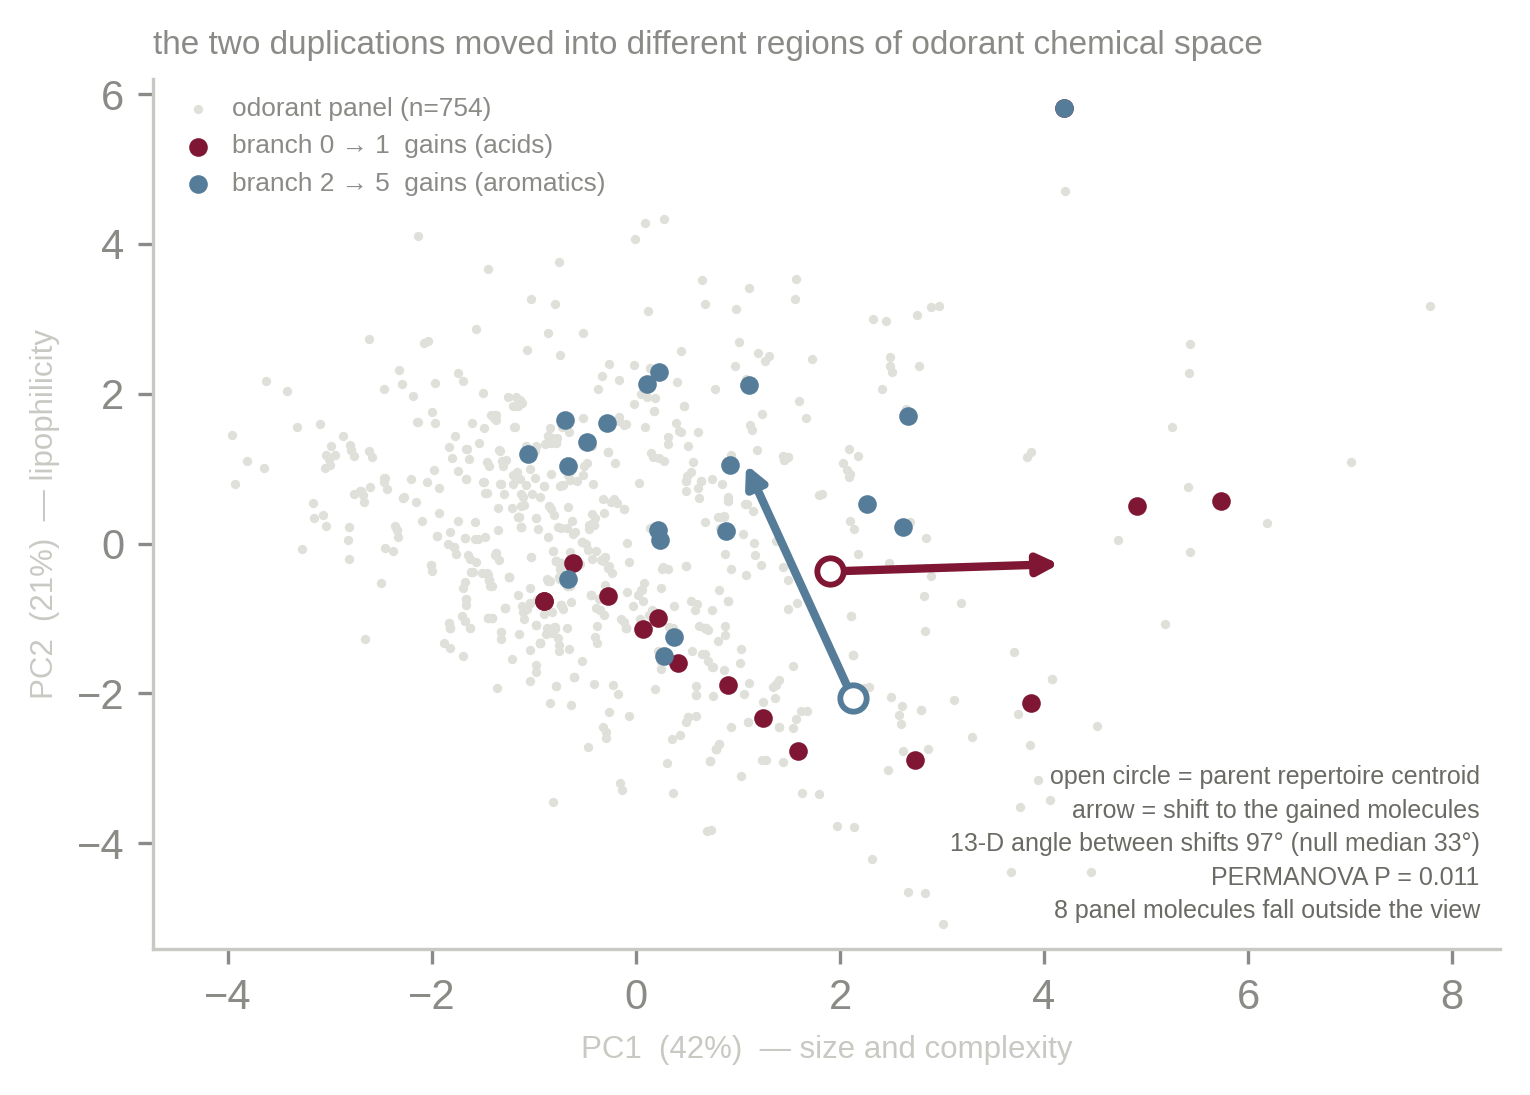

In [25]:
fig, ax = plt.subplots(figsize=(FIGSIZE[0] * 1.3, FIGSIZE[1] * 1.25))
ax.scatter(pc["PC1"], pc["PC2"], s=5, color="#e0e0db", linewidth=0, zorder=1,
           label=f"odorant panel (n={len(pc)})")

for key, col, name in [("dup1", CLASS1_COL, "branch 0 \u2192 1  gains (acids)"),
                       ("dup2", CLASS2_COL, "branch 2 \u2192 5  gains (aromatics)")]:
    d = DUPS[key]
    G = pc.loc[d["gained"]]
    ax.scatter(G["PC1"], G["PC2"], s=20, color=col, linewidth=0, zorder=3, label=name)
    par = pc.loc[sorted(d["parent_set"])].mean().values
    gai = G.mean().values
    ax.annotate("", xy=gai, xytext=par, zorder=4,
                arrowprops=dict(arrowstyle="-|>", color=col, lw=2.0, shrinkA=0, shrinkB=0))
    ax.scatter(*par, s=40, facecolor="white", edgecolor=col, linewidth=1.4, zorder=5)

# a handful of very large molecules stretch PC1; clip the view rather than the data
xlo, xhi = np.percentile(pc["PC1"], [0.5, 99.0])
ylo, yhi = np.percentile(pc["PC2"], [0.5, 99.5])
pad_x, pad_y = 0.10 * (xhi - xlo), 0.10 * (yhi - ylo)
ax.set_xlim(xlo - pad_x, xhi + pad_x); ax.set_ylim(ylo - pad_y, yhi + pad_y)
n_out = int(((pc["PC1"] > xhi + pad_x) | (pc["PC1"] < xlo - pad_x) |
             (pc["PC2"] > yhi + pad_y) | (pc["PC2"] < ylo - pad_y)).sum())

ax.set_xlabel(f"PC1  ({100*evr[0]:.0f}%)  \u2014 size and complexity", fontsize=7.5)
ax.set_ylabel(f"PC2  ({100*evr[1]:.0f}%)  \u2014 lipophilicity", fontsize=7.5)
ax.set_title("the two duplications moved into different regions of odorant chemical space",
             fontsize=8, loc="left")
ax.legend(frameon=False, fontsize=6.3, loc="upper left", handletextpad=0.3, borderpad=0.2)
ax.text(0.985, 0.03,
        f"open circle = parent repertoire centroid\narrow = shift to the gained molecules\n"
        f"13-D angle between shifts {OBS_ANGLE:.0f}\u00b0 (null median {np.median(null):.0f}\u00b0)\n"
        f"PERMANOVA P = {permanova_p:.3f}\n"
        f"{n_out} panel molecules fall outside the view",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=6, color="#6b6b66",
        linespacing=1.5)
for s in ("top", "right"): ax.spines[s].set_visible(False)
plt.tight_layout(); save_fig(fig, "05_optE_pca_chemspace"); plt.show()


### Should losses count in the shift vector?

The vector used above is built from what each branch **gained**. That leaves out the ligands a
branch **lost**, and on the Class I branch the omission is not small: it drops 17 of node 0's 21
ligands, exactly as many as it gains. Three definitions are compared here, two of which account
for loss, plus a check on whether the loss itself was chemically selective.


In [26]:
mean_z = lambda g: Z13.loc[sorted(g), D13].mean().values

SETS = {}
for k, d in DUPS.items():
    P, C = d["parent_set"], d["child_set"]
    SETS[k] = dict(par=P, chi=C, gain=C - P, lost=P - C, ret=P & C)
    print(f"{k}: parent {len(P):3d}  child {len(C):3d}  retained {len(P & C):3d}"
          f"  gained {len(C - P):3d}  lost {len(P - C):3d}")

SHIFT_DEFS = {
    "A  gained - parent (as reported)":  lambda k: mean_z(SETS[k]["gain"]) - mean_z(SETS[k]["par"]),
    "B  child - parent (loss-aware)":    lambda k: mean_z(SETS[k]["chi"])  - mean_z(SETS[k]["par"]),
    "C  gained - lost (turnover)":       lambda k: mean_z(SETS[k]["gain"]) - mean_z(SETS[k]["lost"]),
}

_rng = np.random.default_rng(0)
rows = []
for name, f in SHIFT_DEFS.items():
    obs = angle(f("dup1"), f("dup2"))
    draws = []
    for _ in range(2000):
        vv = []
        for k in ("dup1", "dup2"):
            g = _rng.choice(pan, len(SETS[k]["gain"]), replace=False)
            if name.startswith("C"):
                if not SETS[k]["lost"]:
                    vv = None; break
                l = _rng.choice(pan, len(SETS[k]["lost"]), replace=False)
                vv.append(Z13.loc[g, D13].mean().values - Z13.loc[l, D13].mean().values)
            elif name.startswith("B"):
                child = sorted(set(SETS[k]["ret"]) | set(g))
                vv.append(Z13.loc[child, D13].mean().values - mean_z(SETS[k]["par"]))
            else:
                vv.append(Z13.loc[g, D13].mean().values - mean_z(SETS[k]["par"]))
        if vv:
            draws.append(angle(vv[0], vv[1]))
    draws = np.array(draws)
    rows.append({"definition": name, "angle": round(obs, 1),
                 "null_median": round(float(np.median(draws)), 1),
                 "null_max": round(float(draws.max()), 1),
                 "draws_ge_obs": int((draws >= obs).sum()), "n_draws": len(draws)})

loss_defs = pd.DataFrame(rows)
print()
print(loss_defs.to_string(index=False))
print("\nB reproduces A, so the result survives accounting for losses.")
print("C is unusable: differencing two independent draws is near-orthogonal by construction,")
print("so its null already sits at ~90 deg and the observed angle carries no information.")
save_table(loss_defs, "05_orthogonality_loss_definitions")


dup1: parent  21  child  21  retained   4  gained  17  lost  17
dup2: parent   8  child  27  retained   7  gained  20  lost   1



                      definition  angle  null_median  null_max  draws_ge_obs  n_draws
A  gained - parent (as reported)   96.7         33.3      78.2             0     2000
  B  child - parent (loss-aware)   98.4         35.8      84.2             0     2000
     C  gained - lost (turnover)  106.6         89.5     157.9           566     2000

B reproduces A, so the result survives accounting for losses.
C is unusable: differencing two independent draws is near-orthogonal by construction,
so its null already sits at ~90 deg and the observed angle carries no information.


In [27]:
# Was the loss itself chemically selective? Background is the PARENT's own repertoire,
# not the panel -- the question is which of node 0's ligands the branch chose to drop.
d = DUPS["dup1"]
lost, ret = sorted(d["parent_set"] - d["child_set"]), sorted(d["parent_set"] & d["child_set"])
print(f"branch 0 -> 1: retained {len(ret)} of {len(d['parent_set'])} "
      f"({100*len(ret)/len(d['parent_set']):.0f}%), lost {len(lost)}")
for grp in ["aromatic_ring", "carboxylic_acid"]:
    a = int(fg_panel.loc[lost, grp].sum()); b = len(lost) - a
    c = int(fg_panel.loc[ret, grp].sum());  e = len(ret) - c
    orr, pv = fisher_exact([[a, b], [c, e]])
    print(f"  {grp:16s} lost {a}/{len(lost)} ({100*a/len(lost):3.0f}%)   "
          f"retained {c}/{len(ret)} ({100*c/len(ret):3.0f}%)   OR = {orr:.2f}   P = {pv:.2f}")
print("\n-> the loss is NOT selective: 11 of 13 aromatics dropped against 6 of 8 non-aromatics.")
print("   Do not write that the branch traded aromatics for acids; it discarded most of what it")
print("   had, indiscriminately, and the chemical signal is carried entirely by the gain.")

save_table(pd.DataFrame([{
    "branch": "0 -> 1", "parent_n": len(d["parent_set"]), "retained": len(ret), "lost": len(lost),
    "pct_retained": round(100 * len(ret) / len(d["parent_set"])),
    "lost_pct_aromatic": round(100 * fg_panel.loc[lost, "aromatic_ring"].mean()),
    "retained_pct_aromatic": round(100 * fg_panel.loc[ret, "aromatic_ring"].mean()),
    "fisher_P": round(float(fisher_exact([[int(fg_panel.loc[lost, "aromatic_ring"].sum()),
                                           len(lost) - int(fg_panel.loc[lost, "aromatic_ring"].sum())],
                                          [int(fg_panel.loc[ret, "aromatic_ring"].sum()),
                                           len(ret) - int(fg_panel.loc[ret, "aromatic_ring"].sum())]])[1]), 2),
}]), "05_loss_selectivity")


branch 0 -> 1: retained 4 of 21 (19%), lost 17
  aromatic_ring    lost 11/17 ( 65%)   retained 2/4 ( 50%)   OR = 1.83   P = 0.62
  carboxylic_acid  lost 0/17 (  0%)   retained 0/4 (  0%)   OR = nan   P = 1.00

-> the loss is NOT selective: 11 of 13 aromatics dropped against 6 of 8 non-aromatics.
   Do not write that the branch traded aromatics for acids; it discarded most of what it
   had, indiscriminately, and the chemical signal is carried entirely by the gain.
